In [58]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from scipy.sparse import csr_matrix

import joblib, re, os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR = '/mnt/user-data/uploads'
pd.set_option('display.max_columns', 50)

In [59]:
import pandas as pd

DATA_DIR = r"C:\Users\BANOTHU VINOD KUMAR\OneDrive\Desktop\dataset\\"

books = pd.read_csv(
    DATA_DIR + "Books.csv",
    encoding="latin-1",
    low_memory=False
)

users = pd.read_csv(
    DATA_DIR + "Users.csv",
    encoding="latin-1",
    low_memory=False
)

ratings = pd.read_csv(
    DATA_DIR + "Ratings.csv",
    encoding="latin-1",
    low_memory=False
)

print("Books :", books.shape)
print("Users :", users.shape)
print("Ratings:", ratings.shape)

Books : (271360, 8)
Users : (278858, 3)
Ratings: (1149780, 3)


In [60]:
print("Books shape:", books.shape)
print("Users shape:", users.shape)
print("Ratings shape:", ratings.shape)

print("\nMissing values:")
display(books.isnull().sum())
display(users.isnull().sum())
display(ratings.isnull().sum())

print("\nDuplicate rows:")
print("Books:", books.duplicated().sum())
print("Users:", users.duplicated().sum())
print("Ratings:", ratings.duplicated().sum())

Books shape: (271360, 8)
Users shape: (278858, 3)
Ratings shape: (1149780, 3)

Missing values:


ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

User-ID          0
Location         0
Age         110762
dtype: int64

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64


Duplicate rows:
Books: 0
Users: 0
Ratings: 0


In [61]:
# --- Books: dedupe, fix types, drop unusable rows ---

books = books.drop_duplicates(subset='ISBN').copy()

books = books.dropna(
    subset=['Book-Title', 'Book-Author']
)

# Year-Of-Publication -> numeric
books['Year-Of-Publication'] = pd.to_numeric(
    books['Year-Of-Publication'],
    errors='coerce'
)

# Keep only reasonable publication years
current_year = 2026

books.loc[
    (books['Year-Of-Publication'] < 1450) |
    (books['Year-Of-Publication'] > current_year),
    'Year-Of-Publication'
] = np.nan

# Handle missing publisher
books['Publisher'] = books['Publisher'].fillna('Unknown')


# Text cleaning function
def clean_text(s):
    if pd.isna(s):
        return ''
    
    s = re.sub(
        r'[^a-zA-Z0-9\s]',
        ' ',
        str(s)
    )
    
    return re.sub(
        r'\s+',
        ' ',
        s
    ).strip()


# Apply text cleaning
books['Book-Title'] = books['Book-Title'].apply(clean_text)

books['Book-Author'] = books['Book-Author'].apply(clean_text)


print('Books after cleaning:', books.shape)

Books after cleaning: (271358, 8)


In [62]:
print("Shape:", books.shape)

print("\nMissing values:")
display(books.isnull().sum())

print("\nDuplicate ISBNs:")
print(books['ISBN'].duplicated().sum())

print("\nSample cleaned data:")
display(
    books[['ISBN', 'Book-Title', 'Book-Author',
           'Year-Of-Publication', 'Publisher']].head(10)
)

Shape: (271358, 8)

Missing values:


ISBN                      0
Book-Title                0
Book-Author               0
Year-Of-Publication    4634
Publisher                 0
Image-URL-S               0
Image-URL-M               0
Image-URL-L               3
dtype: int64


Duplicate ISBNs:
0

Sample cleaned data:


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher
0,0195153448,Classical Mythology,Mark P O Morford,2002.0,Oxford University Press
1,0002005018,Clara Callan,Richard Bruce Wright,2001.0,HarperFlamingo Canada
2,0060973129,Decision in Normandy,Carlo D Este,1991.0,HarperPerennial
3,0374157065,Flu The Story of the Great Influenza Pandemic ...,Gina Bari Kolata,1999.0,Farrar Straus Giroux
4,0393045218,The Mummies of Urumchi,E J W Barber,1999.0,W. W. Norton &amp; Company
5,0399135782,The Kitchen God s Wife,Amy Tan,1991.0,Putnam Pub Group
6,0425176428,What If The World s Foremost Military Historia...,Robert Cowley,2000.0,Berkley Publishing Group
7,0671870432,PLEADING GUILTY,Scott Turow,1993.0,Audioworks
8,0679425608,Under the Black Flag The Romance and the Reali...,David Cordingly,1996.0,Random House
9,074322678X,Where You ll Find Me And Other Stories,Ann Beattie,2002.0,Scribner


In [63]:
# --- Users: fix age outliers ---

users['Age'] = pd.to_numeric(
    users['Age'],
    errors='coerce'
)

# Replace unrealistic ages with NaN
users.loc[
    (users['Age'] < 5) | (users['Age'] > 100),
    'Age'
] = np.nan


# --- Clean Location ---

users['Location'] = (
    users['Location']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
)


# --- Split Location into City / State / Country ---

loc_split = users['Location'].str.split(
    ',',
    n=2,
    expand=True
)

users['City'] = (
    loc_split[0]
    .fillna('Unknown')
    .str.strip()
    .str.lower()
)

users['State'] = (
    loc_split[1]
    .fillna('Unknown')
    .str.strip()
    .str.lower()
)

users['Country'] = (
    loc_split[2]
    .fillna('Unknown')
    .str.strip()
    .str.lower()
)


print('Users after cleaning:', users.shape)

print(
    'Missing ages:',
    users['Age'].isnull().sum(),
    f"({users['Age'].isnull().mean():.1%})"
)

Users after cleaning: (278858, 6)
Missing ages: 112010 (40.2%)


In [64]:
display(
    users[
        ['User-ID', 'Location', 'City', 'State', 'Country', 'Age']
    ].head(10)
)

,User-ID,Location,City,State,Country,Age
0,1,"nyc, new york, usa",nyc,new york,usa,NaN
1,2,"stockton, california, usa",stockton,california,usa,18.0
2,3,"moscow, yukon territory, russia",moscow,yukon territory,russia,NaN
3,4,"porto, v.n.gaia, portugal",porto,v.n.gaia,portugal,17.0
4,5,"farnborough, hants, united kingdom",farnborough,hants,united kingdom,NaN
5,6,"santa monica, california, usa",santa monica,california,usa,61.0
6,7,"washington, dc, usa",washington,dc,usa,NaN
7,8,"timmins, ontario, canada",timmins,ontario,canada,NaN
8,9,"germantown, tennessee, usa",germantown,tennessee,usa,NaN
9,10,"albacete, wisconsin, spain",albacete,wisconsin,spain,26.0


In [65]:
# Handle invalid and missing Age values

users['Age'] = pd.to_numeric(users['Age'], errors='coerce')

# Replace unrealistic ages with NaN
users.loc[(users['Age'] < 5) | (users['Age'] > 100), 'Age'] = np.nan

# Fill missing Age values with median age
users['Age'] = users['Age'].fillna(users['Age'].median())

# Verify missing values
users.isnull().sum()

User-ID     0
Location    0
Age         0
City        0
State       0
Country     0
dtype: int64

In [66]:
print("Missing values:")
display(users.isnull().sum())

Missing values:


User-ID     0
Location    0
Age         0
City        0
State       0
Country     0
dtype: int64

In [67]:
# --- Ratings: clean and validate ---

# Convert rating to numeric
ratings['Book-Rating'] = pd.to_numeric(
    ratings['Book-Rating'],
    errors='coerce'
)

# Remove missing ratings
ratings = ratings.dropna(
    subset=['Book-Rating', 'ISBN', 'User-ID']
)

# Keep ratings in valid range: 0–10
ratings = ratings[
    ratings['Book-Rating'].between(0, 10)
]

# Keep only ratings for books that exist in Books dataset
ratings = ratings[
    ratings['ISBN'].isin(books['ISBN'])
]

# Keep only ratings from users that exist in Users dataset
ratings = ratings[
    ratings['User-ID'].isin(users['User-ID'])
]

# Remove duplicate User + Book interactions
ratings = ratings.drop_duplicates(
    subset=['User-ID', 'ISBN']
)

# ------------------------------------------------
# Separate explicit ratings
# 0 = implicit interaction
# 1–10 = explicit rating
# ------------------------------------------------

explicit_ratings = ratings[
    ratings['Book-Rating'] > 0
].copy()

print('Ratings (all)      :', ratings.shape)
print('Ratings (explicit) :', explicit_ratings.shape)

Ratings (all)      : (1031134, 3)
Ratings (explicit) : (383840, 3)


In [68]:
display(
    ratings['Book-Rating']
    .value_counts()
    .sort_index()
)

Book-Rating
0     647294
1       1481
2       2375
3       5118
4       7617
5      45355
6      31687
7      66402
8      91803
9      60778
10     71224
Name: count, dtype: int64

In [69]:
display(
    explicit_ratings['Book-Rating']
    .value_counts()
    .sort_index()
)

Book-Rating
1      1481
2      2375
3      5118
4      7617
5     45355
6     31687
7     66402
8     91803
9     60778
10    71224
Name: count, dtype: int64

In [70]:
print(
    "Duplicate User-ID + ISBN:",
    ratings.duplicated(
        subset=['User-ID', 'ISBN']
    ).sum()
)

Duplicate User-ID + ISBN: 0


In [71]:
print("Missing values in Ratings:")
display(ratings.isnull().sum())

Missing values in Ratings:


User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [72]:
# --- Merge into one clean master table ---
master = (
    explicit_ratings
    .merge(books, on='ISBN', how='left')
    .merge(users, on='User-ID', how='left')
)

print('Master shape:', master.shape)
master.head()

Master shape: (383840, 15)


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age,City,State,Country
0,276726,0155061224,5,Rites of Passage,Judith Rae,2001.0,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa",32.0,seattle,washington,usa
1,276729,052165615X,3,Help Level 1,Philip Prowse,1999.0,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia",16.0,rijeka,n/a,croatia
2,276729,0521795028,6,The Amsterdam Connection Level 4 Cambridge Eng...,Sue Leather,2001.0,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia",16.0,rijeka,n/a,croatia
3,276744,038550120X,7,A Painted House,JOHN GRISHAM,2001.0,Doubleday,http://images.amazon.com/images/P/038550120X.0...,http://images.amazon.com/images/P/038550120X.0...,http://images.amazon.com/images/P/038550120X.0...,"torrance, california, usa",32.0,torrance,california,usa
4,276747,0060517794,9,Little Altars Everywhere,Rebecca Wells,2003.0,HarperTorch,http://images.amazon.com/images/P/0060517794.0...,http://images.amazon.com/images/P/0060517794.0...,http://images.amazon.com/images/P/0060517794.0...,"iowa city, iowa, usa",25.0,iowa city,iowa,usa


In [73]:
explicit_ratings.merge(books, on='ISBN', how='left')

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276726,0155061224,5,Rites of Passage,Judith Rae,2001.0,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
1,276729,052165615X,3,Help Level 1,Philip Prowse,1999.0,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
2,276729,0521795028,6,The Amsterdam Connection Level 4 Cambridge Eng...,Sue Leather,2001.0,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...
3,276744,038550120X,7,A Painted House,JOHN GRISHAM,2001.0,Doubleday,http://images.amazon.com/images/P/038550120X.0...,http://images.amazon.com/images/P/038550120X.0...,http://images.amazon.com/images/P/038550120X.0...
4,276747,0060517794,9,Little Altars Everywhere,Rebecca Wells,2003.0,HarperTorch,http://images.amazon.com/images/P/0060517794.0...,http://images.amazon.com/images/P/0060517794.0...,http://images.amazon.com/images/P/0060517794.0...
...,...,...,...,...,...,...,...,...,...,...
383835,276704,0743211383,7,Dreamcatcher,Stephen King,2001.0,Scribner,http://images.amazon.com/images/P/0743211383.0...,http://images.amazon.com/images/P/0743211383.0...,http://images.amazon.com/images/P/0743211383.0...
383836,276704,0806917695,5,Perplexing Lateral Thinking Puzzles Scholastic...,Paul Sloane,1997.0,Sterling Publishing,http://images.amazon.com/images/P/0806917695.0...,http://images.amazon.com/images/P/0806917695.0...,http://images.amazon.com/images/P/0806917695.0...
383837,276704,1563526298,9,Get Clark Smart The Ultimate Guide for the Sav...,Clark Howard,2000.0,Longstreet Press,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...
383838,276709,0515107662,10,The Sherbrooke Bride Bride Trilogy Paperback,Catherine Coulter,1996.0,Jove Books,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...


In [74]:
top_rated_books = (master.groupby('Book-Title').agg(avg_rating=('Book-Rating', 'mean'), num_ratings=('Book-Rating', 'count')).query('num_ratings >= 20').sort_values('avg_rating', ascending=False).head(10))
top_rated_books

,avg_rating,num_ratings
Book-Title,,
Harry Potter and the Chamber of Secrets Postcard Book,9.869565,23
The Authoritative Calvin and Hobbes Calvin and Hobbes,9.600000,20
Calvin and Hobbes,9.583333,24
My Sister s Keeper A Novel Picoult Jodi,9.545455,22
The Giving Tree,9.423077,26
Where the Sidewalk Ends Poems and Drawings,9.400000,25
Homicidal Psycho Jungle Cat A Calvin and Hobbes Collection,9.350000,20
Johnny Got His Gun,9.333333,24
The Two Towers The Lord of the Rings Part 2,9.330882,136


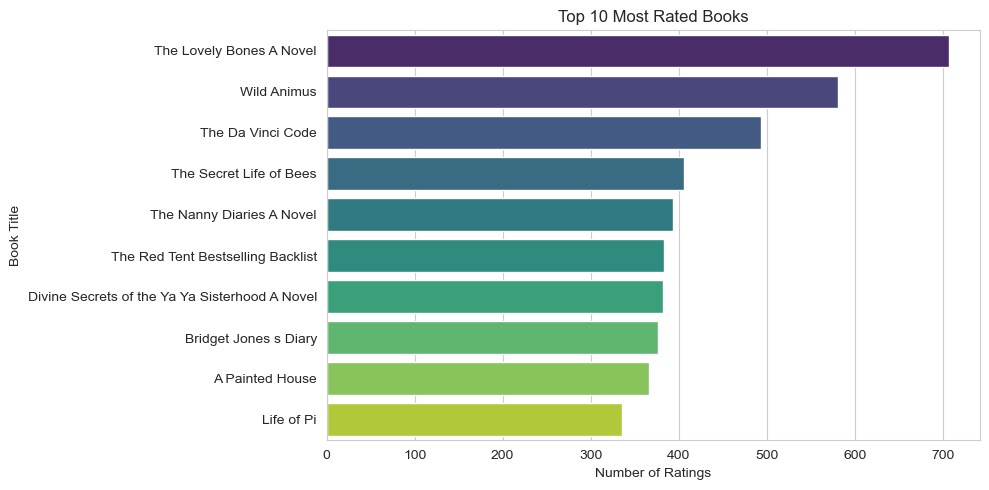

In [75]:
most_popular = master['Book-Title'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=most_popular.values, y=most_popular.index, palette='viridis')
plt.title('Top 10 Most Rated Books')
plt.xlabel('Number of Ratings')
plt.ylabel('Book Title')
plt.tight_layout()
plt.show()

<Axes: ylabel='Book-Title'>

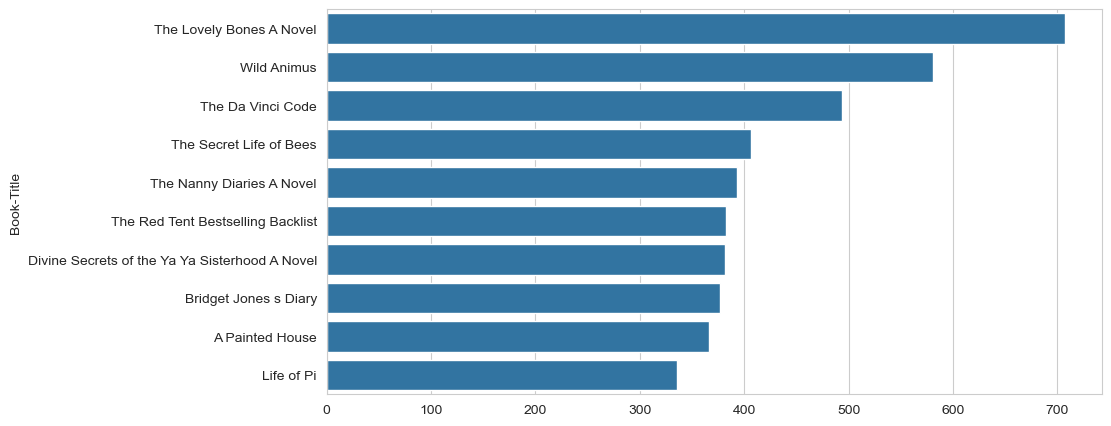

In [76]:
sns.barplot(x=most_popular.values, y=most_popular.index)

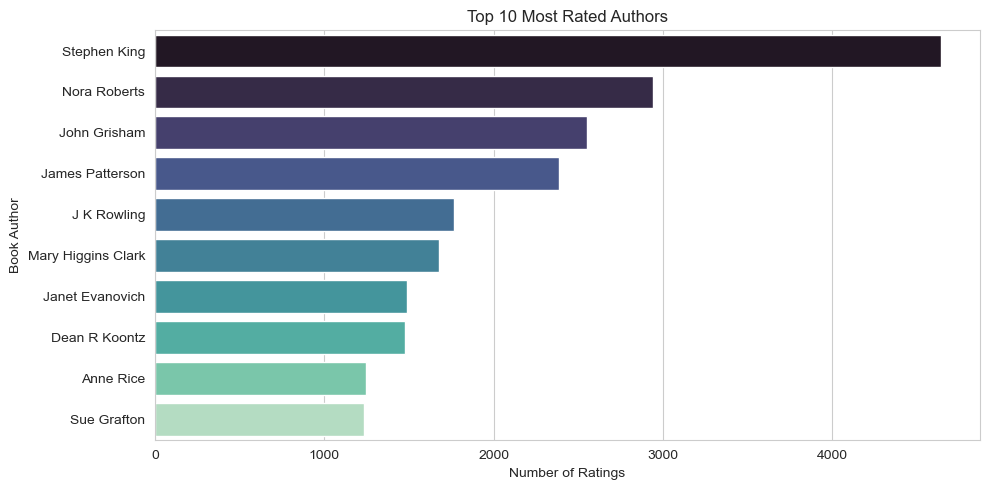

In [77]:
top_authors = master['Book-Author'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_authors.values, y=top_authors.index, palette='mako')
plt.title('Top 10 Most Rated Authors')
plt.xlabel('Number of Ratings')
plt.ylabel('Book Author')
plt.tight_layout()
plt.show()

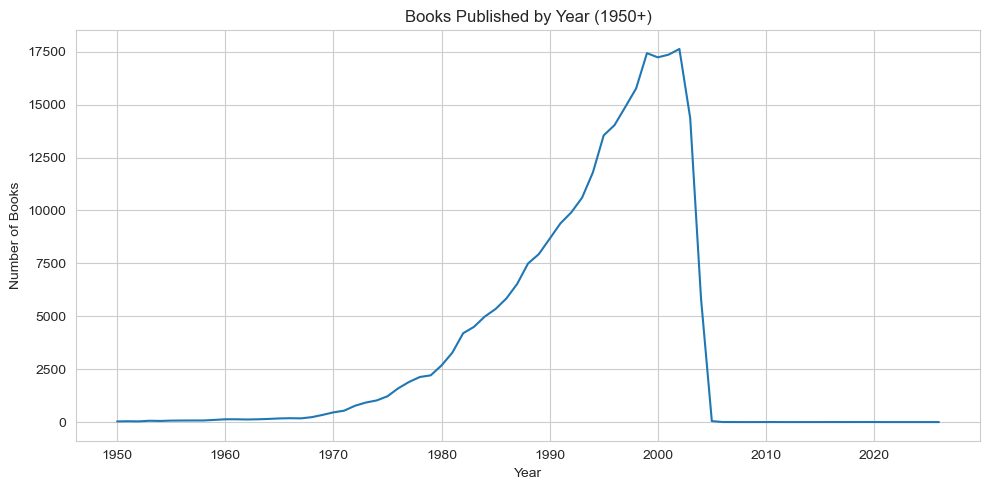

In [78]:
plt.figure(figsize=(10, 5))

year_counts = books['Year-Of-Publication'].dropna().value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 1950]

plt.plot(year_counts.index, year_counts.values)

plt.title('Books Published by Year (1950+)')
plt.xlabel('Year')
plt.ylabel('Number of Books')
plt.tight_layout()
plt.show()

In [79]:
books['Year-Of-Publication'].dropna()

0         2002.0
1         2001.0
2         1991.0
3         1999.0
4         1999.0
           ...  
271355    1988.0
271356    1991.0
271357    2004.0
271358    1996.0
271359    2000.0
Name: Year-Of-Publication, Length: 266724, dtype: float64

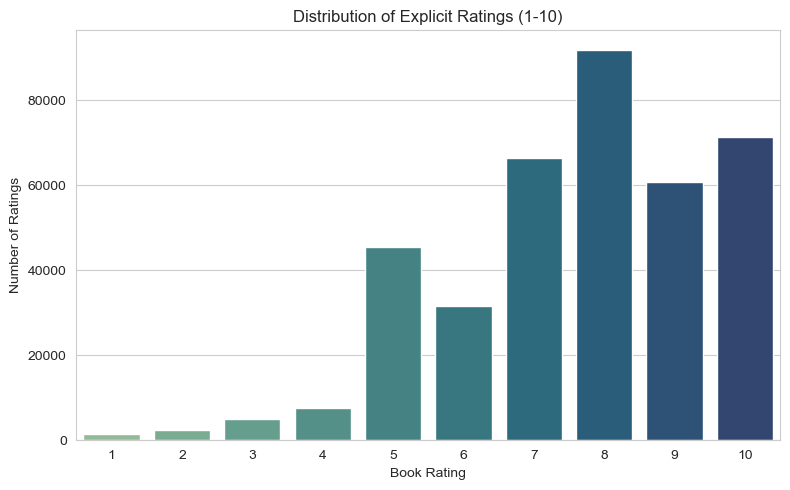

Average rating: 7.63
Median rating : 8.0


In [80]:
plt.figure(figsize=(8, 5))

sns.countplot(x='Book-Rating', data=explicit_ratings, palette='crest')

plt.title('Distribution of Explicit Ratings (1-10)')
plt.xlabel('Book Rating')
plt.ylabel('Number of Ratings')
plt.tight_layout()
plt.show()

print('Average rating:', round(explicit_ratings['Book-Rating'].mean(), 2))
print('Median rating :', explicit_ratings['Book-Rating'].median())

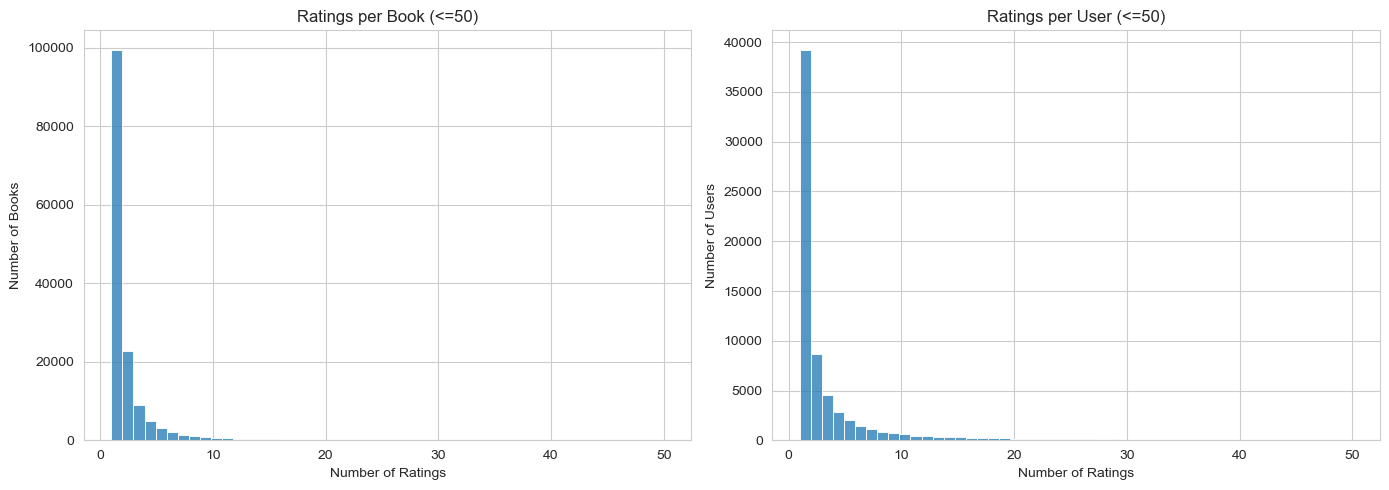

Median ratings per book: 1.0
Median ratings per user: 1.0


In [81]:
ratings_per_book = explicit_ratings.groupby('ISBN').size()
ratings_per_user = explicit_ratings.groupby('User-ID').size()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(ratings_per_book[ratings_per_book <= 50], bins=50, ax=ax[0])
ax[0].set_title('Ratings per Book (<=50)')
ax[0].set_xlabel('Number of Ratings')
ax[0].set_ylabel('Number of Books')

sns.histplot(ratings_per_user[ratings_per_user <= 50], bins=50, ax=ax[1])
ax[1].set_title('Ratings per User (<=50)')
ax[1].set_xlabel('Number of Ratings')
ax[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

print('Median ratings per book:', ratings_per_book.median())
print('Median ratings per user:', ratings_per_user.median())

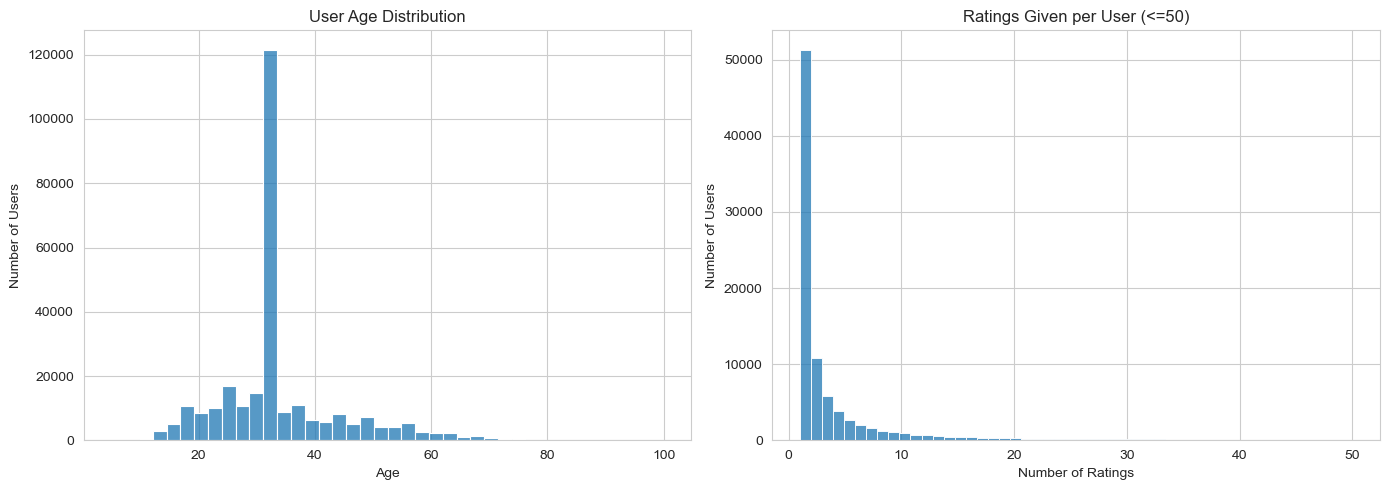

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(users['Age'].dropna(), bins=40, ax=ax[0])
ax[0].set_title('User Age Distribution')
ax[0].set_xlabel('Age')
ax[0].set_ylabel('Number of Users')

active_users = ratings['User-ID'].value_counts()

sns.histplot(active_users[active_users <= 50], bins=50, ax=ax[1])
ax[1].set_title('Ratings Given per User (<=50)')
ax[1].set_xlabel('Number of Ratings')
ax[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

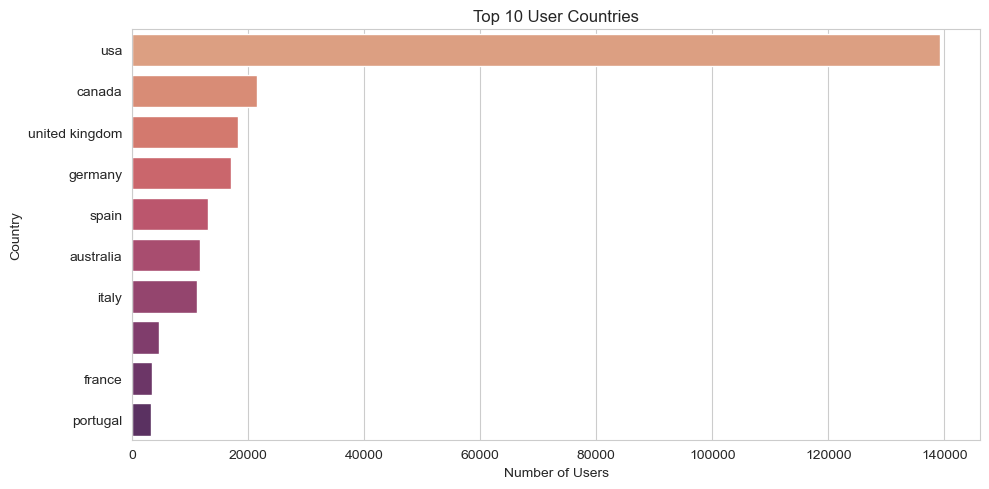

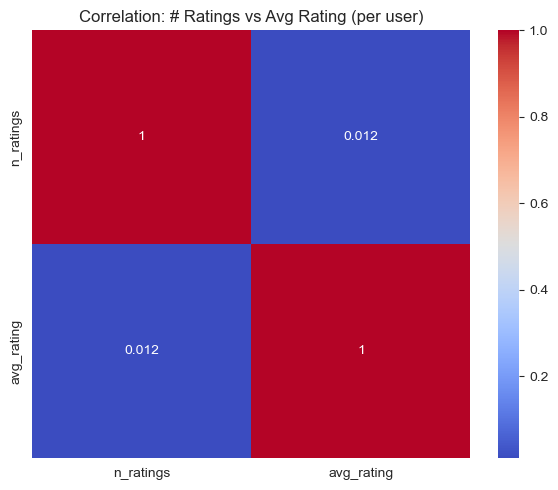

In [83]:
top_countries = users['Country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='flare')
plt.title('Top 10 User Countries')
plt.xlabel('Number of Users')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

corr_data = master.groupby('User-ID').agg(
    n_ratings=('Book-Rating', 'count'),
    avg_rating=('Book-Rating', 'mean')
).reset_index()

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_data[['n_ratings', 'avg_rating']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation: # Ratings vs Avg Rating (per user)')
plt.tight_layout()
plt.show()



In [84]:
# ============================================================
# FEATURE ENGINEERING + FEATURE SCALING
# ============================================================

from sklearn.preprocessing import StandardScaler

# -------------------------
# 1. Book-level features
# -------------------------

book_features = (
    explicit_ratings.groupby('ISBN')['Book-Rating']
    .agg(
        Book_Average_Rating='mean',
        Book_Rating_Count='count',
        Book_Rating_Std='std'
    )
    .reset_index()
)

# -------------------------
# 2. User-level features
# -------------------------

user_features = (
    explicit_ratings.groupby('User-ID')['Book-Rating']
    .agg(
        User_Average_Rating='mean',
        User_Rating_Count='count',
        User_Rating_Std='std'
    )
    .reset_index()
)

# -------------------------
# 3. Handle missing std values
# -------------------------

book_features['Book_Rating_Std'] = book_features['Book_Rating_Std'].fillna(0)
user_features['User_Rating_Std'] = user_features['User_Rating_Std'].fillna(0)

# -------------------------
# 4. Merge book features
# -------------------------

explicit_ratings = explicit_ratings.merge(
    book_features,
    on='ISBN',
    how='left'
)

# -------------------------
# 5. Merge user features
# -------------------------

explicit_ratings = explicit_ratings.merge(
    user_features,
    on='User-ID',
    how='left'
)

# -------------------------
# 6. Features for scaling
# -------------------------

scaling_features = [
    'Book_Average_Rating',
    'Book_Rating_Count',
    'Book_Rating_Std',
    'User_Average_Rating',
    'User_Rating_Count',
    'User_Rating_Std'
]

# -------------------------
# 7. Feature scaling
# -------------------------

scaler = StandardScaler()

explicit_ratings[scaling_features] = scaler.fit_transform(
    explicit_ratings[scaling_features]
)

# -------------------------
# 8. Verification
# -------------------------

print("Feature engineering and scaling completed.")
print("\nNew features:")
print(scaling_features)

print("\nDataset shape:", explicit_ratings.shape)

print("\nMissing values in engineered features:")
print(explicit_ratings[scaling_features].isnull().sum())

explicit_ratings.head()


Feature engineering and scaling completed.

New features:
['Book_Average_Rating', 'Book_Rating_Count', 'Book_Rating_Std', 'User_Average_Rating', 'User_Rating_Count', 'User_Rating_Std']

Dataset shape: (383840, 9)

Missing values in engineered features:
Book_Average_Rating    0
Book_Rating_Count      0
Book_Rating_Std        0
User_Average_Rating    0
User_Rating_Count      0
User_Rating_Std        0
dtype: int64


,User-ID,ISBN,Book-Rating,Book_Average_Rating,Book_Rating_Count,Book_Rating_Std,User_Average_Rating,User_Rating_Count,User_Rating_Std
0,276726,0155061224,5,-2.066044,-0.392622,-1.305371,-2.234945,-0.272667,-1.885011
1,276729,052165615X,3,-3.639157,-0.392622,-1.305371,-2.660375,-0.271798,1.167632
2,276729,0521795028,6,-1.279487,-0.392622,-1.305371,-2.660375,-0.271798,1.167632
3,276744,038550120X,7,-0.036533,0.941014,0.792212,-0.533228,-0.272667,-1.885011
4,276747,0060517794,9,0.293627,0.090821,0.275382,0.317631,-0.269191,-0.445981


In [85]:
# ============================================================
# PREPARE DATA FOR 5 RECOMMENDATION MODELS
# ============================================================

# ------------------------------------------------------------
# 1. POPULARITY MODEL
# ------------------------------------------------------------

popularity_data = explicit_ratings[
    [
        'ISBN',
        'Book-Title',
        'Book-Author',
        'Publisher',
        'Book_Average_Rating',
        'Book_Rating_Count'
    ]
].drop_duplicates(subset='ISBN').copy()


# ------------------------------------------------------------
# 2. CONTENT-BASED MODEL
# ------------------------------------------------------------

content_data = explicit_ratings[
    [
        'ISBN',
        'Book-Title',
        'Book-Author',
        'Publisher'
    ]
].drop_duplicates(subset='ISBN').copy()

content_data['Content'] = (
    content_data['Book-Title'].fillna('') + ' ' +
    content_data['Book-Author'].fillna('') + ' ' +
    content_data['Publisher'].fillna('')
)


# ------------------------------------------------------------
# 3. COLLABORATIVE FILTERING
# ------------------------------------------------------------

collaborative_data = explicit_ratings[
    [
        'User-ID',
        'ISBN',
        'Book-Rating'
    ]
].copy()


# ------------------------------------------------------------
# 4. SVD
# ------------------------------------------------------------

svd_data = explicit_ratings[
    [
        'User-ID',
        'ISBN',
        'Book-Rating'
    ]
].copy()


# ------------------------------------------------------------
# 5. HYBRID MODEL
# ------------------------------------------------------------

hybrid_data = explicit_ratings[
    [
        'User-ID',
        'ISBN',
        'Book-Rating',
        'Book-Title',
        'Book-Author',
        'Publisher',
        'Book_Average_Rating',
        'Book_Rating_Count',
        'User_Average_Rating',
        'User_Rating_Count'
    ]
].copy()


# ============================================================
# VERIFICATION
# ============================================================

print("Popularity data      :", popularity_data.shape)
print("Content data         :", content_data.shape)
print("Collaborative data   :", collaborative_data.shape)
print("SVD data             :", svd_data.shape)
print("Hybrid data          :", hybrid_data.shape)

KeyError: "['Book-Title', 'Book-Author', 'Publisher'] not in index"

In [ ]:
# ============================================================
# 5 RECOMMENDATION MODELS - DATA PREPARATION
# ============================================================

# ============================================================
# MODEL 1: POPULARITY-BASED RECOMMENDATION
# ============================================================

popularity_data = (
    explicit_ratings[
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Publisher',
            'Book_Average_Rating',
            'Book_Rating_Count'
        ]
    ]
    .drop_duplicates(subset='ISBN')
    .copy()
)

print("MODEL 1 - Popularity")
print("Shape:", popularity_data.shape)

In [ ]:
# ============================================================
# MODEL 2: CONTENT-BASED RECOMMENDATION
# ============================================================

content_data = (
    explicit_ratings[
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Publisher'
        ]
    ]
    .drop_duplicates(subset='ISBN')
    .copy()
)

# Combine text information
content_data['Content'] = (
    content_data['Book-Title'].fillna('') + ' ' +
    content_data['Book-Author'].fillna('') + ' ' +
    content_data['Publisher'].fillna('')
)

print("\nMODEL 2 - Content-Based")
print("Shape:", content_data.shape)

In [86]:
# ============================================================
# MODEL 3: COLLABORATIVE FILTERING
# ============================================================

collaborative_data = explicit_ratings[
    [
        'User-ID',
        'ISBN',
        'Book-Rating'
    ]
].copy()

print("\nMODEL 3 - Collaborative Filtering")
print("Shape:", collaborative_data.shape)


MODEL 3 - Collaborative Filtering
Shape: (383840, 3)


In [87]:
# ============================================================
# MODEL 4: SVD
# ============================================================

svd_data = explicit_ratings[
    [
        'User-ID',
        'ISBN',
        'Book-Rating'
    ]
].copy()

print("\nMODEL 4 - SVD")
print("Shape:", svd_data.shape)


MODEL 4 - SVD
Shape: (383840, 3)


In [89]:
# ============================================================
# ADD BOOK INFORMATION TO EXPLICIT RATINGS
# ============================================================

book_info = (
    books[
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Publisher'
        ]
    ]
    .drop_duplicates(subset='ISBN')
    .copy()
)

explicit_ratings = explicit_ratings.merge(
    book_info,
    on='ISBN',
    how='left'
)

print("Explicit ratings after book information merge:")
print("Shape:", explicit_ratings.shape)

print("\nBook information columns:")
print(
    explicit_ratings[
        [
            'Book-Title',
            'Book-Author',
            'Publisher'
        ]
    ].notna().sum()
)


# ============================================================
# MODEL 4: SVD
# ============================================================

svd_data = explicit_ratings[
    [
        'User-ID',
        'ISBN',
        'Book-Rating'
    ]
].copy()

print("\nMODEL 4 - SVD")
print("Shape:", svd_data.shape)


# ============================================================
# MODEL 5: HYBRID RECOMMENDATION
# ============================================================

hybrid_data = explicit_ratings[
    [
        'User-ID',
        'ISBN',
        'Book-Rating',
        'Book-Title',
        'Book-Author',
        'Publisher',
        'Book_Average_Rating',
        'Book_Rating_Count',
        'User_Average_Rating',
        'User_Rating_Count'
    ]
].copy()

print("\nMODEL 5 - Hybrid")
print("Shape:", hybrid_data.shape)

Explicit ratings after book information merge:
Shape: (383840, 12)

Book information columns:
Book-Title     383840
Book-Author    383840
Publisher      383840
dtype: int64

MODEL 4 - SVD
Shape: (383840, 3)

MODEL 5 - Hybrid
Shape: (383840, 10)


In [90]:

# ============================================================
# FINAL VERIFICATION
# ============================================================

print("\n" + "=" * 60)
print("5 MODEL DATASETS PREPARED SUCCESSFULLY")
print("=" * 60)

print("Popularity      :", popularity_data.shape)
print("Content-Based   :", content_data.shape)
print("Collaborative   :", collaborative_data.shape)
print("SVD             :", svd_data.shape)
print("Hybrid          :", hybrid_data.shape)


5 MODEL DATASETS PREPARED SUCCESSFULLY
Popularity      : (149834, 7)
Content-Based   : (149834, 5)
Collaborative   : (383840, 3)
SVD             : (383840, 3)
Hybrid          : (383840, 10)


In [91]:
# ============================================================
# MODEL 1: POPULARITY-BASED RECOMMENDATION
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Calculate weighted popularity score
# ------------------------------------------------------------

# Minimum number of ratings required
m = 20

# Overall average rating
C = popularity_data['Book_Average_Rating'].mean()

# Weighted rating formula
popularity_data['Popularity_Score'] = (
    (
        popularity_data['Book_Rating_Count'] /
        (popularity_data['Book_Rating_Count'] + m)
    ) * popularity_data['Book_Average_Rating']
    +
    (
        m /
        (popularity_data['Book_Rating_Count'] + m)
    ) * C
)

# ------------------------------------------------------------
# 2. Sort books by popularity score
# ------------------------------------------------------------

popularity_rank = (
    popularity_data
    .sort_values(
        'Popularity_Score',
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 3. Recommendation function
# ------------------------------------------------------------

def popularity_recommend(top_n=10):

    recommendations = popularity_rank[
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Publisher',
            'Book_Average_Rating',
            'Book_Rating_Count',
            'Popularity_Score'
        ]
    ].head(top_n)

    return recommendations


# ------------------------------------------------------------
# 4. Test the model
# ------------------------------------------------------------

popularity_recommend(10)

,ISBN,Book-Title,Book-Author,Publisher,Book_Average_Rating,Book_Rating_Count,Popularity_Score
0,059035342X,Harry Potter and the Sorcerer s Stone Harry Po...,J K Rowling,Arthur A. Levine Books,1.032437,4.808560,0.137230
1,0385504209,The Da Vinci Code,Dan Brown,Doubleday,0.636029,7.709220,0.120654
2,0316666343,The Lovely Bones A Novel,Alice Sebold,"Little, Brown",0.439368,11.376720,0.109588
3,043935806X,Harry Potter and the Order of the Phoenix Book 5,J K Rowling,Scholastic,1.106911,3.024822,0.077662
4,0446310786,To Kill a Mockingbird,Harper Lee,Little Brown &amp; Company,1.036078,3.158185,0.073929
5,0142001740,The Secret Life of Bees,Sue Monk Kidd,Penguin Books,0.649755,4.708538,0.060681
6,0439064872,Harry Potter and the Chamber of Secrets Book 2,J K Rowling,Scholastic,0.909555,2.741424,0.041045
7,0312195516,The Red Tent Bestselling Backlist,Anita Diamant,Picador USA,0.437384,5.975492,0.040558
8,0439139597,Harry Potter and the Goblet of Fire Book 4,J K Rowling,Scholastic,1.286870,1.874560,0.038961
9,0385484518,Tuesdays with Morrie An Old Man a Young Man an...,MITCH ALBOM,Doubleday,0.777359,2.924799,0.031126


In [92]:
# ============================================================
# MODEL 2: CONTENT-BASED RECOMMENDATION — TF-IDF
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Prepare text data
# ------------------------------------------------------------

content_data['Content'] = (
    content_data['Book-Title'].fillna('') + ' ' +
    content_data['Book-Author'].fillna('') + ' ' +
    content_data['Publisher'].fillna('')
)

# ------------------------------------------------------------
# 2. Create TF-IDF features
# ------------------------------------------------------------

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

tfidf_matrix = tfidf.fit_transform(
    content_data['Content']
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

# ------------------------------------------------------------
# 3. Create ISBN → index mapping
# ------------------------------------------------------------

isbn_to_index = pd.Series(
    content_data.index,
    index=content_data['ISBN']
).to_dict()

# ------------------------------------------------------------
# 4. Content-based recommendation function
# ------------------------------------------------------------

def content_recommend(isbn, top_n=10):

    # Check whether ISBN exists
    if isbn not in isbn_to_index:
        return pd.DataFrame(
            columns=[
                'ISBN',
                'Book-Title',
                'Book-Author',
                'Publisher',
                'Similarity_Score'
            ]
        )

    # Get index of selected book
    book_index = isbn_to_index[isbn]

    # Calculate similarity with all books
    similarity_scores = cosine_similarity(
        tfidf_matrix[book_index],
        tfidf_matrix
    ).flatten()

    # Get indices of highest similarity
    similar_indices = np.argsort(
        similarity_scores
    )[::-1]

    # Remove the input book itself
    similar_indices = [
        i for i in similar_indices
        if i != book_index
    ]

    # Select top N books
    similar_indices = similar_indices[:top_n]

    # Create recommendation dataframe
    recommendations = content_data.iloc[
        similar_indices
    ][
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Publisher'
        ]
    ].copy()

    # Add similarity scores
    recommendations['Similarity_Score'] = (
        similarity_scores[similar_indices]
    )

    return recommendations.reset_index(drop=True)


# ------------------------------------------------------------
# 5. Test the model
# ------------------------------------------------------------

test_isbn = content_data['ISBN'].iloc[0]

print("Test ISBN:", test_isbn)

content_recommend(
    test_isbn,
    top_n=10
)

TF-IDF matrix shape: (149834, 10000)
Test ISBN: 0155061224


,ISBN,Book-Title,Book-Author,Publisher,Similarity_Score
0,0838465943,Weaving It Together Book 4,Milada Broukal,Heinle &amp; Heinle Publishers,0.471785
1,0838481248,De Paseo,Long,Heinle &amp; Heinle Publishers,0.454385
2,0155006614,Grammaire Francaise,Jacqueline Ollivier,Heinle &amp; Heinle Publishers,0.447153
3,0345446941,Rites of Passage Odyssey of a Grunt,Robert Peterson,Ballantine Books,0.437178
4,0838461336,Tu Diras,John R Gutierrez,Heinle &amp; Heinle Publishers,0.431300
5,0345353315,Where Two Worlds Touch Spiritual Rites of Passage,Gloria D Karpinski,Ballantine Books,0.387324
6,0838434762,Horizontes Cultura Y Literatura,Graciela Ascarrunz Gilman,Heinle &amp; Heinle Publishers,0.379775
7,2070421465,Trilogie maritime tome 1 Rites de passage,William Golding,Gallimard,0.373133
8,0679435506,Illuminata Thoughts Prayers Rites of Passage,Marianne Williamson,Random House,0.367471
9,0571117880,Rites of Passage,William Golding,Faber Faber Inc,0.365823


In [93]:
# ============================================================
# MODEL 3: COLLABORATIVE FILTERING — KNN
# MEMORY-EFFICIENT SPARSE VERSION
# ============================================================

import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# ------------------------------------------------------------
# 1. Prepare collaborative data
# ------------------------------------------------------------

cf_data = collaborative_data[
    ['User-ID', 'ISBN', 'Book-Rating']
].copy()

cf_data = cf_data.drop_duplicates(
    subset=['User-ID', 'ISBN']
)

print("Collaborative data shape:", cf_data.shape)


# ------------------------------------------------------------
# 2. Create integer mappings
# ------------------------------------------------------------

user_ids = cf_data['User-ID'].unique()
isbn_ids = cf_data['ISBN'].unique()

user_to_index = {
    user_id: i
    for i, user_id in enumerate(user_ids)
}

isbn_to_index_cf = {
    isbn: i
    for i, isbn in enumerate(isbn_ids)
}


# ------------------------------------------------------------
# 3. Convert User-ID and ISBN to matrix indices
# ------------------------------------------------------------

row_indices = cf_data['User-ID'].map(
    user_to_index
).values

column_indices = cf_data['ISBN'].map(
    isbn_to_index_cf
).values

ratings_values = cf_data['Book-Rating'].astype(
    np.float32
).values


# ------------------------------------------------------------
# 4. Create SPARSE User-Book Matrix
# ------------------------------------------------------------

user_book_sparse = csr_matrix(
    (
        ratings_values,
        (row_indices, column_indices)
    ),
    shape=(
        len(user_ids),
        len(isbn_ids)
    ),
    dtype=np.float32
)

print("Sparse User-Book matrix:", user_book_sparse.shape)
print(
    "Number of ratings stored:",
    user_book_sparse.nnz
)


# ------------------------------------------------------------
# 5. Train KNN
# ------------------------------------------------------------

knn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=6,
    n_jobs=-1
)

knn_model.fit(user_book_sparse)

print("KNN Collaborative Filtering model trained.")


# ------------------------------------------------------------
# 6. Recommendation function
# ------------------------------------------------------------

def collaborative_recommend(user_id, top_n=10):

    # Check user
    if user_id not in user_to_index:
        return pd.DataFrame(
            columns=[
                'ISBN',
                'Book-Title',
                'Book-Author',
                'Publisher',
                'CF_Score'
            ]
        )

    user_index = user_to_index[user_id]

    # Find similar users
    distances, indices = knn_model.kneighbors(
        user_book_sparse[user_index],
        n_neighbors=min(
            6,
            user_book_sparse.shape[0]
        )
    )

    similarities = 1 - distances[0]

    # --------------------------------------------------------
    # Get books already rated by target user
    # --------------------------------------------------------

    target_row = user_book_sparse[user_index]

    rated_indices = set(
        target_row.indices
    )

    scores = {}

    # --------------------------------------------------------
    # Collect recommendations from similar users
    # --------------------------------------------------------

    for similar_index, similarity in zip(
        indices[0],
        similarities
    ):

        # Skip target user
        if similar_index == user_index:
            continue

        similar_row = user_book_sparse[
            similar_index
        ]

        for book_index, rating in zip(
            similar_row.indices,
            similar_row.data
        ):

            # Skip books already rated
            if book_index in rated_indices:
                continue

            isbn = isbn_ids[book_index]

            scores[isbn] = (
                scores.get(isbn, 0)
                +
                float(similarity) * float(rating)
            )

    # --------------------------------------------------------
    # No recommendations
    # --------------------------------------------------------

    if not scores:
        return pd.DataFrame(
            columns=[
                'ISBN',
                'Book-Title',
                'Book-Author',
                'Publisher',
                'CF_Score'
            ]
        )

    # --------------------------------------------------------
    # Create recommendation dataframe
    # --------------------------------------------------------

    recommendations = (
        pd.DataFrame(
            scores.items(),
            columns=['ISBN', 'CF_Score']
        )
        .sort_values(
            'CF_Score',
            ascending=False
        )
        .head(top_n)
    )

    # --------------------------------------------------------
    # Add book information
    # --------------------------------------------------------

    recommendations = recommendations.merge(
        book_info,
        on='ISBN',
        how='left'
    )

    recommendations = recommendations[
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Publisher',
            'CF_Score'
        ]
    ]

    return recommendations.reset_index(
        drop=True
    )


# ============================================================
# TEST MODEL
# ============================================================

test_user = cf_data['User-ID'].iloc[0]

print("\nTest User-ID:", test_user)

collaborative_recommend(
    test_user,
    top_n=10
)

Collaborative data shape: (383840, 3)
Sparse User-Book matrix: (68091, 149834)
Number of ratings stored: 383840
KNN Collaborative Filtering model trained.

Test User-ID: 276726


,ISBN,Book-Title,Book-Author,Publisher,CF_Score
0,0060934417,Bel Canto A Novel,Ann Patchett,Perennial,0.0
1,0345465083,Seabiscuit,LAURA HILLENBRAND,Ballantine Books,0.0
2,0373802099,Staying Dead,Laura Anne Gilman,Luna,0.0
3,0451459172,Paper Mage,Leah R Cutter,Roc,0.0
4,0786887583,Napalm amp Silly Putty,George Carlin,Hyperion,0.0
5,0380008785,Cornelius Chronicles Cornelius Chronicles,Michael Moorcock,Harper Mass Market Paperbacks (Mm),0.0
6,038531292X,The Gift,Danielle Steel,Delacorte Press,0.0
7,0060911131,The War Prayer Harper Colophon Books,Mark Twain,Perennial,0.0
8,0786861347,Don t Stand Too Close to a Naked Man,Tim Allen,Hyperion Books,0.0


In [94]:
# ============================================================
# MODEL 4: SVD — MEMORY-EFFICIENT VERSION
# ============================================================

from sklearn.decomposition import TruncatedSVD
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Use the sparse User-Book matrix from Model 3
# ------------------------------------------------------------

# user_book_sparse was already created in Model 3
# user_ids contains the corresponding User-IDs
# isbn_ids contains the corresponding ISBNs

print("SVD input sparse matrix:", user_book_sparse.shape)
print("Number of ratings:", user_book_sparse.nnz)


# ------------------------------------------------------------
# 2. Train Truncated SVD
# ------------------------------------------------------------

n_components = min(
    30,
    user_book_sparse.shape[0] - 1,
    user_book_sparse.shape[1] - 1
)

svd_model = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

user_factors = svd_model.fit_transform(
    user_book_sparse
)

book_factors = svd_model.components_

print("SVD model trained successfully.")
print("Latent factors:", n_components)
print(
    "Explained variance:",
    round(
        svd_model.explained_variance_ratio_.sum(),
        4
    )
)


# ------------------------------------------------------------
# 3. Create User-ID mapping
# ------------------------------------------------------------

svd_user_to_index = {
    user_id: index
    for index, user_id in enumerate(user_ids)
}


# ------------------------------------------------------------
# 4. Create ISBN mapping
# ------------------------------------------------------------

svd_isbn_to_index = {
    isbn: index
    for index, isbn in enumerate(isbn_ids)
}


# ------------------------------------------------------------
# 5. SVD Recommendation Function
# ------------------------------------------------------------

def svd_recommend(user_id, top_n=10):

    # Check user
    if user_id not in svd_user_to_index:

        return pd.DataFrame(
            columns=[
                'ISBN',
                'Book-Title',
                'Book-Author',
                'Publisher',
                'SVD_Score'
            ]
        )

    # --------------------------------------------------------
    # Get user index
    # --------------------------------------------------------

    user_index = svd_user_to_index[user_id]

    # --------------------------------------------------------
    # Get user's latent factors
    # --------------------------------------------------------

    user_vector = user_factors[user_index]

    # --------------------------------------------------------
    # Predict scores for all books
    # --------------------------------------------------------

    predicted_scores = np.dot(
        user_vector,
        book_factors
    )

    # --------------------------------------------------------
    # Find books already rated by user
    # --------------------------------------------------------

    rated_book_indices = set(
        user_book_sparse[user_index].indices
    )

    # --------------------------------------------------------
    # Rank books
    # --------------------------------------------------------

    ranked_indices = np.argsort(
        predicted_scores
    )[::-1]

    recommendations = []

    for book_index in ranked_indices:

        # Skip books already rated
        if book_index in rated_book_indices:
            continue

        isbn = isbn_ids[book_index]

        recommendations.append({
            'ISBN': isbn,
            'SVD_Score': float(
                predicted_scores[book_index]
            )
        })

        if len(recommendations) >= top_n:
            break

    # --------------------------------------------------------
    # No recommendations
    # --------------------------------------------------------

    if not recommendations:

        return pd.DataFrame(
            columns=[
                'ISBN',
                'Book-Title',
                'Book-Author',
                'Publisher',
                'SVD_Score'
            ]
        )

    # --------------------------------------------------------
    # Convert to DataFrame
    # --------------------------------------------------------

    recommendations = pd.DataFrame(
        recommendations
    )

    # --------------------------------------------------------
    # Add book information
    # --------------------------------------------------------

    recommendations = recommendations.merge(
        book_info,
        on='ISBN',
        how='left'
    )

    recommendations = recommendations[
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Publisher',
            'SVD_Score'
        ]
    ]

    return recommendations.reset_index(
        drop=True
    )


# ============================================================
# TEST SVD MODEL
# ============================================================

test_user = user_ids[0]

print("\nTest User-ID:", test_user)

svd_result = svd_recommend(
    test_user,
    top_n=10
)

svd_result

SVD input sparse matrix: (68091, 149834)
Number of ratings: 383840
SVD model trained successfully.
Latent factors: 30
Explained variance: 0.1001

Test User-ID: 276726


,ISBN,Book-Title,Book-Author,Publisher,SVD_Score
0,0312195516,The Red Tent Bestselling Backlist,Anita Diamant,Picador USA,2.827097e-07
1,0316666343,The Lovely Bones A Novel,Alice Sebold,"Little, Brown",2.747258e-07
2,0385504209,The Da Vinci Code,Dan Brown,Doubleday,2.434234e-07
3,067976402X,Snow Falling on Cedars,David Guterson,Vintage Books USA,2.334272e-07
4,059035342X,Harry Potter and the Sorcerer s Stone Harry Po...,J K Rowling,Arthur A. Levine Books,2.040509e-07
5,0345370775,Jurassic Park,Michael Crichton,Ballantine Books,2.028447e-07
6,0439064864,Harry Potter and the Chamber of Secrets Book 2,J K Rowling,Scholastic,1.927288e-07
7,0345361792,A Prayer for Owen Meany,John Irving,Ballantine Books,1.922922e-07
8,0446310786,To Kill a Mockingbird,Harper Lee,Little Brown &amp; Company,1.914500e-07
9,0446672211,Where the Heart Is Oprah s Book Club Paperback,Billie Letts,Warner Books,1.903873e-07


In [95]:
# ============================================================
# MODEL 5: HYBRID RECOMMENDATION SYSTEM
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# STEP 1: HYBRID MODEL WEIGHTS
# ------------------------------------------------------------

CONTENT_WEIGHT = 0.40
COLLAB_WEIGHT = 0.40
POPULARITY_WEIGHT = 0.20

TOP_N = 10
CANDIDATE_N = 100


# ------------------------------------------------------------
# STEP 2: PREPARE POPULARITY SCORES
# ------------------------------------------------------------

popularity_scores = (
    popularity_rank[
        ['ISBN', 'Popularity_Score']
    ]
    .drop_duplicates('ISBN')
    .set_index('ISBN')['Popularity_Score']
)


# ------------------------------------------------------------
# STEP 3: HYBRID RECOMMENDATION FUNCTION
# ------------------------------------------------------------

def hybrid_recommend(user_id, top_n=10):

    # --------------------------------------------------------
    # Check user
    # --------------------------------------------------------

    if user_id not in user_to_index:

        return pd.DataFrame(
            columns=[
                'ISBN',
                'Book-Title',
                'Book-Author',
                'Publisher',
                'Content_Score',
                'CF_Score',
                'Popularity_Score',
                'Hybrid_Score'
            ]
        )


    # --------------------------------------------------------
    # Get user's rated books
    # --------------------------------------------------------

    user_history = collaborative_data[
        collaborative_data['User-ID'] == user_id
    ]

    if user_history.empty:

        return pd.DataFrame(
            columns=[
                'ISBN',
                'Book-Title',
                'Book-Author',
                'Publisher',
                'Content_Score',
                'CF_Score',
                'Popularity_Score',
                'Hybrid_Score'
            ]
        )


    history_isbns = set(
        user_history['ISBN']
    )


    # --------------------------------------------------------
    # Select liked books
    # Rating >= 8 means liked
    # --------------------------------------------------------

    liked_books = user_history[
        user_history['Book-Rating'] >= 8
    ]['ISBN'].tolist()


    # If user has no rating >= 8,
    # use highest-rated books instead

    if len(liked_books) == 0:

        liked_books = (
            user_history
            .sort_values(
                'Book-Rating',
                ascending=False
            )
            .head(5)['ISBN']
            .tolist()
        )

    else:

        liked_books = liked_books[:5]


    # --------------------------------------------------------
    # CONTENT-BASED CANDIDATES
    # --------------------------------------------------------

    content_scores = {}


    for isbn in liked_books:

        if isbn not in isbn_to_index:
            continue

        book_index = isbn_to_index[isbn]

        similarity_scores = cosine_similarity(
            tfidf_matrix[book_index],
            tfidf_matrix
        ).flatten()


        # Get only top candidate books
        candidate_indices = np.argsort(
            similarity_scores
        )[::-1][:CANDIDATE_N + 1]


        for candidate_index in candidate_indices:

            candidate_isbn = content_data.iloc[
                candidate_index
            ]['ISBN']


            # Don't recommend already rated books

            if candidate_isbn in history_isbns:
                continue


            score = float(
                similarity_scores[candidate_index]
            )


            # Keep maximum similarity
            # from user's liked books

            if (
                candidate_isbn not in content_scores
                or
                score > content_scores[candidate_isbn]
            ):

                content_scores[candidate_isbn] = score


    # --------------------------------------------------------
    # COLLABORATIVE FILTERING CANDIDATES
    # --------------------------------------------------------

    cf_result = collaborative_recommend(
        user_id,
        top_n=CANDIDATE_N
    )


    if not cf_result.empty:

        cf_scores = (
            cf_result[
                ['ISBN', 'CF_Score']
            ]
            .drop_duplicates('ISBN')
            .set_index('ISBN')['CF_Score']
            .to_dict()
        )

    else:

        cf_scores = {}


    # --------------------------------------------------------
    # POPULARITY CANDIDATES
    # --------------------------------------------------------

    popularity_result = (
        popularity_rank
        .head(CANDIDATE_N)
        [['ISBN', 'Popularity_Score']]
        .copy()
    )


    popularity_dict = (
        popularity_result
        .set_index('ISBN')['Popularity_Score']
        .to_dict()
    )


    # --------------------------------------------------------
    # COMBINE ALL CANDIDATES
    # --------------------------------------------------------

    candidate_isbns = (
        set(content_scores.keys())
        |
        set(cf_scores.keys())
        |
        set(popularity_dict.keys())
    )


    # Remove books already rated by user

    candidate_isbns = [
        isbn
        for isbn in candidate_isbns
        if isbn not in history_isbns
    ]


    if len(candidate_isbns) == 0:

        return pd.DataFrame(
            columns=[
                'ISBN',
                'Book-Title',
                'Book-Author',
                'Publisher',
                'Content_Score',
                'CF_Score',
                'Popularity_Score',
                'Hybrid_Score'
            ]
        )


    # --------------------------------------------------------
    # CREATE SCORE DATAFRAME
    # --------------------------------------------------------

    hybrid_df = pd.DataFrame({
        'ISBN': candidate_isbns
    })


    hybrid_df['Content_Score'] = (
        hybrid_df['ISBN']
        .map(content_scores)
        .fillna(0)
    )


    hybrid_df['CF_Score'] = (
        hybrid_df['ISBN']
        .map(cf_scores)
        .fillna(0)
    )


    hybrid_df['Popularity_Score'] = (
        hybrid_df['ISBN']
        .map(popularity_dict)
        .fillna(0)
    )


    # --------------------------------------------------------
    # STEP 4: MIN-MAX NORMALIZATION
    # --------------------------------------------------------

    def min_max_scale(series):

        min_value = series.min()
        max_value = series.max()

        if max_value == min_value:

            return pd.Series(
                np.zeros(len(series)),
                index=series.index
            )

        return (
            (series - min_value)
            /
            (max_value - min_value)
        )


    hybrid_df['Content_Normalized'] = min_max_scale(
        hybrid_df['Content_Score']
    )


    hybrid_df['CF_Normalized'] = min_max_scale(
        hybrid_df['CF_Score']
    )


    hybrid_df['Popularity_Normalized'] = min_max_scale(
        hybrid_df['Popularity_Score']
    )


    # --------------------------------------------------------
    # STEP 5: FINAL HYBRID SCORE
    # --------------------------------------------------------

    hybrid_df['Hybrid_Score'] = (

        CONTENT_WEIGHT *
        hybrid_df['Content_Normalized']

        +

        COLLAB_WEIGHT *
        hybrid_df['CF_Normalized']

        +

        POPULARITY_WEIGHT *
        hybrid_df['Popularity_Normalized']
    )


    # --------------------------------------------------------
    # STEP 6: SORT RECOMMENDATIONS
    # --------------------------------------------------------

    hybrid_df = hybrid_df.sort_values(
        'Hybrid_Score',
        ascending=False
    )


    # --------------------------------------------------------
    # STEP 7: GET TOP N BOOKS
    # --------------------------------------------------------

    hybrid_df = hybrid_df.head(top_n)


    # --------------------------------------------------------
    # STEP 8: ADD BOOK INFORMATION
    # --------------------------------------------------------

    hybrid_df = hybrid_df.merge(
        book_info,
        on='ISBN',
        how='left'
    )


    # --------------------------------------------------------
    # STEP 9: FINAL COLUMNS
    # --------------------------------------------------------

    hybrid_df = hybrid_df[
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Publisher',
            'Content_Score',
            'CF_Score',
            'Popularity_Score',
            'Hybrid_Score'
        ]
    ]


    return hybrid_df.reset_index(drop=True)


# ============================================================
# TEST HYBRID MODEL
# ============================================================

test_user = user_ids[0]

print("Test User-ID:", test_user)

hybrid_result = hybrid_recommend(
    test_user,
    top_n=10
)

hybrid_result

Test User-ID: 276726


,ISBN,Book-Title,Book-Author,Publisher,Content_Score,CF_Score,Popularity_Score,Hybrid_Score
0,0838465943,Weaving It Together Book 4,Milada Broukal,Heinle &amp; Heinle Publishers,0.471785,0.0,0.0,0.400000
1,0838481248,De Paseo,Long,Heinle &amp; Heinle Publishers,0.454385,0.0,0.0,0.385247
2,0155006614,Grammaire Francaise,Jacqueline Ollivier,Heinle &amp; Heinle Publishers,0.447153,0.0,0.0,0.379116
3,0345446941,Rites of Passage Odyssey of a Grunt,Robert Peterson,Ballantine Books,0.437178,0.0,0.0,0.370658
4,0838461336,Tu Diras,John R Gutierrez,Heinle &amp; Heinle Publishers,0.431300,0.0,0.0,0.365675
5,0345353315,Where Two Worlds Touch Spiritual Rites of Passage,Gloria D Karpinski,Ballantine Books,0.387324,0.0,0.0,0.328390
6,0838434762,Horizontes Cultura Y Literatura,Graciela Ascarrunz Gilman,Heinle &amp; Heinle Publishers,0.379775,0.0,0.0,0.321990
7,2070421465,Trilogie maritime tome 1 Rites de passage,William Golding,Gallimard,0.373133,0.0,0.0,0.316358
8,0679435506,Illuminata Thoughts Prayers Rites of Passage,Marianne Williamson,Random House,0.367471,0.0,0.0,0.311558
9,0571117880,Rites of Passage,William Golding,Faber Faber Inc,0.365823,0.0,0.0,0.310160


In [96]:
# ============================================================
# STEP 1: LEAKAGE-SAFE TRAIN / TEST SPLIT
# ============================================================

import pandas as pd
import numpy as np

RANDOM_STATE = 42
RELEVANCE_THRESHOLD = 7
MIN_RELEVANT_BOOKS = 3

# ------------------------------------------------------------
# 1. Start from cleaned explicit ratings
# ------------------------------------------------------------

evaluation_data = collaborative_data[
    collaborative_data['Book-Rating'] >= RELEVANCE_THRESHOLD
].copy()

print("Relevant ratings:", len(evaluation_data))


# ------------------------------------------------------------
# 2. Keep users with at least 3 relevant books
# ------------------------------------------------------------

user_counts = (
    evaluation_data
    .groupby('User-ID')['ISBN']
    .count()
)

eligible_users = user_counts[
    user_counts >= MIN_RELEVANT_BOOKS
].index

evaluation_data = evaluation_data[
    evaluation_data['User-ID'].isin(eligible_users)
].copy()

print("Eligible users:", evaluation_data['User-ID'].nunique())


# ------------------------------------------------------------
# 3. Hold out ONE relevant book for each user
# ------------------------------------------------------------

rng = np.random.RandomState(RANDOM_STATE)

test_indices = []

for user_id, group in evaluation_data.groupby('User-ID'):

    selected_index = rng.choice(
        group.index
    )

    test_indices.append(selected_index)


# ------------------------------------------------------------
# 4. Create TEST data
# ------------------------------------------------------------

test_data = evaluation_data.loc[
    test_indices
].copy()


# ------------------------------------------------------------
# 5. Create TRAIN data
# ------------------------------------------------------------

train_data = collaborative_data.drop(
    test_data.index
).copy()


# ------------------------------------------------------------
# 6. Safety check
# ------------------------------------------------------------

train_pairs = set(
    zip(
        train_data['User-ID'],
        train_data['ISBN']
    )
)

test_pairs = set(
    zip(
        test_data['User-ID'],
        test_data['ISBN']
    )
)

leakage = train_pairs.intersection(
    test_pairs
)


print("\n============================================================")
print("TRAIN / TEST SPLIT")
print("============================================================")

print("Train ratings:", len(train_data))
print("Test ratings:", len(test_data))
print("Train users:", train_data['User-ID'].nunique())
print("Test users:", test_data['User-ID'].nunique())
print("Train books:", train_data['ISBN'].nunique())
print("Test books:", test_data['ISBN'].nunique())

print("\nData leakage pairs:", len(leakage))

if len(leakage) == 0:
    print("✓ NO DATA LEAKAGE DETECTED")
else:
    print("✗ DATA LEAKAGE DETECTED")

Relevant ratings: 290207
Eligible users: 15785

TRAIN / TEST SPLIT
Train ratings: 368055
Test ratings: 15785
Train users: 68091
Test users: 15785
Train books: 146494
Test books: 11851

Data leakage pairs: 0
✓ NO DATA LEAKAGE DETECTED


In [97]:
# ============================================================
# STEP 2: TRAIN ALL 5 MODELS USING TRAIN DATA ONLY
# ============================================================

import pandas as pd
import numpy as np

from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# MODEL 1: POPULARITY
# ============================================================

train_book_stats = (
    train_data
    .groupby('ISBN')
    .agg(
        Book_Average_Rating=('Book-Rating', 'mean'),
        Book_Rating_Count=('Book-Rating', 'count')
    )
    .reset_index()
)

m = 20

C = train_book_stats[
    'Book_Average_Rating'
].mean()

train_book_stats['Popularity_Score'] = (
    (
        train_book_stats['Book_Rating_Count']
        /
        (
            train_book_stats['Book_Rating_Count'] + m
        )
    )
    *
    train_book_stats['Book_Average_Rating']
    +
    (
        m
        /
        (
            train_book_stats['Book_Rating_Count'] + m
        )
    )
    *
    C
)

popularity_rank_train = (
    train_book_stats
    .sort_values(
        'Popularity_Score',
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# MODEL 2: CONTENT-BASED
# ============================================================

# Use books that are known in the training interactions
train_isbns = train_data[
    'ISBN'
].unique()

content_data_train = (
    book_info[
        book_info['ISBN'].isin(train_isbns)
    ]
    .drop_duplicates('ISBN')
    .copy()
)

content_data_train['Content'] = (
    content_data_train['Book-Title'].fillna('')
    + ' '
    + content_data_train['Book-Author'].fillna('')
    + ' '
    + content_data_train['Publisher'].fillna('')
)

tfidf_train = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

tfidf_matrix_train = tfidf_train.fit_transform(
    content_data_train['Content']
)

isbn_to_index_train = {
    isbn: index
    for index, isbn in enumerate(
        content_data_train['ISBN']
    )
}


# ============================================================
# MODEL 3: COLLABORATIVE FILTERING
# ============================================================

cf_train = train_data[
    ['User-ID', 'ISBN', 'Book-Rating']
].drop_duplicates(
    ['User-ID', 'ISBN']
).copy()


train_user_ids = cf_train[
    'User-ID'
].unique()

train_isbn_ids = cf_train[
    'ISBN'
].unique()


train_user_to_index = {
    user_id: i
    for i, user_id in enumerate(train_user_ids)
}

train_isbn_to_index = {
    isbn: i
    for i, isbn in enumerate(train_isbn_ids)
}


rows = cf_train['User-ID'].map(
    train_user_to_index
).values

cols = cf_train['ISBN'].map(
    train_isbn_to_index
).values

values = cf_train[
    'Book-Rating'
].astype(
    np.float32
).values


user_book_sparse_train = csr_matrix(
    (
        values,
        (rows, cols)
    ),
    shape=(
        len(train_user_ids),
        len(train_isbn_ids)
    ),
    dtype=np.float32
)


knn_model_train = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=6,
    n_jobs=-1
)

knn_model_train.fit(
    user_book_sparse_train
)


# ============================================================
# MODEL 4: SVD
# ============================================================

n_components = min(
    30,
    user_book_sparse_train.shape[0] - 1,
    user_book_sparse_train.shape[1] - 1
)

svd_model_train = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

user_factors_train = (
    svd_model_train.fit_transform(
        user_book_sparse_train
    )
)

book_factors_train = (
    svd_model_train.components_
)


# ============================================================
# MODEL 5: HYBRID
# ============================================================

# Hybrid uses the three independently trained components:
#
# Content-Based  -> trained using training catalog
# Collaborative  -> trained using train interactions
# Popularity     -> calculated using train ratings
# SVD            -> trained using train interactions


print("============================================================")
print("ALL 5 MODELS TRAINED")
print("============================================================")

print(
    "1. Popularity      : TRAIN only"
)

print(
    "2. Content-Based   : TRAIN catalog only"
)

print(
    "3. Collaborative   : TRAIN interactions only"
)

print(
    "4. SVD             : TRAIN interactions only"
)

print(
    "5. Hybrid          : TRAIN components only"
)

print("\nTraining sparse matrix:",
      user_book_sparse_train.shape)

print(
    "Training ratings:",
    user_book_sparse_train.nnz
)

print(
    "SVD components:",
    n_components
)

ALL 5 MODELS TRAINED
1. Popularity      : TRAIN only
2. Content-Based   : TRAIN catalog only
3. Collaborative   : TRAIN interactions only
4. SVD             : TRAIN interactions only
5. Hybrid          : TRAIN components only

Training sparse matrix: (68091, 146494)
Training ratings: 368055
SVD components: 30


In [98]:
# ============================================================
# STEP 3: TRAIN-ONLY RECOMMENDATION FUNCTIONS
# ============================================================


# ============================================================
# MODEL 1: POPULARITY
# ============================================================

def recommend_popularity_train(
    user_id,
    top_n=10
):

    user_history = set(
        train_data[
            train_data['User-ID'] == user_id
        ]['ISBN']
    )

    result = popularity_rank_train[
        ~popularity_rank_train['ISBN'].isin(
            user_history
        )
    ].head(top_n)

    return result['ISBN'].tolist()


# ============================================================
# MODEL 2: CONTENT
# ============================================================

def recommend_content_train(
    user_id,
    top_n=10
):

    user_history = set(
        train_data[
            train_data['User-ID'] == user_id
        ]['ISBN']
    )

    history = [
        isbn
        for isbn in user_history
        if isbn in isbn_to_index_train
    ]

    if not history:
        return []


    scores = {}


    for isbn in history:

        book_index = isbn_to_index_train[
            isbn
        ]

        similarity = cosine_similarity(
            tfidf_matrix_train[book_index],
            tfidf_matrix_train
        ).flatten()


        candidate_indices = np.argsort(
            similarity
        )[::-1][:101]


        for index in candidate_indices:

            candidate_isbn = (
                content_data_train.iloc[
                    index
                ]['ISBN']
            )

            if candidate_isbn in user_history:
                continue

            score = float(
                similarity[index]
            )

            if (
                candidate_isbn not in scores
                or
                score > scores[candidate_isbn]
            ):
                scores[candidate_isbn] = score


    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        isbn
        for isbn, score in ranked[:top_n]
    ]


# ============================================================
# MODEL 3: COLLABORATIVE
# ============================================================

def recommend_collaborative_train(
    user_id,
    top_n=10
):

    if user_id not in train_user_to_index:
        return []


    user_index = train_user_to_index[
        user_id
    ]


    distances, indices = (
        knn_model_train.kneighbors(
            user_book_sparse_train[
                user_index
            ],
            return_distance=True
        )
    )


    user_history = set(
        train_data[
            train_data['User-ID'] == user_id
        ]['ISBN']
    )


    scores = {}


    for distance, neighbor_index in zip(
        distances[0],
        indices[0]
    ):

        neighbor_user = train_user_ids[
            neighbor_index
        ]

        if neighbor_user == user_id:
            continue


        similarity = 1 - distance


        neighbor_books = train_data[
            train_data['User-ID'] == neighbor_user
        ]


        for _, row in neighbor_books.iterrows():

            isbn = row['ISBN']

            if isbn in user_history:
                continue


            score = (
                similarity
                *
                row['Book-Rating']
            )


            scores[isbn] = (
                scores.get(isbn, 0)
                + score
            )


    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )


    return [
        isbn
        for isbn, score in ranked[:top_n]
    ]


# ============================================================
# MODEL 4: SVD
# ============================================================

def recommend_svd_train(
    user_id,
    top_n=10
):

    if user_id not in train_user_to_index:
        return []


    user_index = train_user_to_index[
        user_id
    ]


    user_vector = user_factors_train[
        user_index
    ]


    predicted_scores = np.dot(
        user_vector,
        book_factors_train
    )


    rated_indices = set(
        user_book_sparse_train[
            user_index
        ].indices
    )


    ranked_indices = np.argsort(
        predicted_scores
    )[::-1]


    recommendations = []


    for book_index in ranked_indices:

        if book_index in rated_indices:
            continue


        isbn = train_isbn_ids[
            book_index
        ]

        recommendations.append(
            isbn
        )


        if len(recommendations) >= top_n:
            break


    return recommendations


# ============================================================
# MODEL 5: HYBRID
# ============================================================

def recommend_hybrid_train(
    user_id,
    top_n=10
):

    # --------------------------------------------------------
    # Get candidates from each TRAINED model
    # --------------------------------------------------------

    content_candidates = (
        recommend_content_train(
            user_id,
            top_n=100
        )
    )

    cf_candidates = (
        recommend_collaborative_train(
            user_id,
            top_n=100
        )
    )

    svd_candidates = (
        recommend_svd_train(
            user_id,
            top_n=100
        )
    )

    popularity_candidates = (
        popularity_rank_train
        ['ISBN']
        .head(100)
        .tolist()
    )


    # --------------------------------------------------------
    # User's training history
    # --------------------------------------------------------

    history = set(
        train_data[
            train_data['User-ID'] == user_id
        ]['ISBN']
    )


    # --------------------------------------------------------
    # Candidate pool
    # --------------------------------------------------------

    candidates = set(
        content_candidates
        +
        cf_candidates
        +
        svd_candidates
        +
        popularity_candidates
    )

    candidates -= history


    if not candidates:
        return []


    # --------------------------------------------------------
    # Rank-based scores
    # --------------------------------------------------------

    content_score = {
        isbn:
        1 - (i / max(len(content_candidates), 1))
        for i, isbn
        in enumerate(content_candidates)
    }

    cf_score = {
        isbn:
        1 - (i / max(len(cf_candidates), 1))
        for i, isbn
        in enumerate(cf_candidates)
    }

    svd_score = {
        isbn:
        1 - (i / max(len(svd_candidates), 1))
        for i, isbn
        in enumerate(svd_candidates)
    }

    popularity_score = {
        isbn:
        1 - (i / max(len(popularity_candidates), 1))
        for i, isbn
        in enumerate(popularity_candidates)
    }


    # --------------------------------------------------------
    # Calculate hybrid score
    # --------------------------------------------------------

    scores = []


    for isbn in candidates:

        content = content_score.get(
            isbn,
            0
        )

        collaborative = cf_score.get(
            isbn,
            0
        )

        svd = svd_score.get(
            isbn,
            0
        )

        popularity = popularity_score.get(
            isbn,
            0
        )


        hybrid_score = (
            0.30 * content
            +
            0.30 * collaborative
            +
            0.20 * svd
            +
            0.20 * popularity
        )


        scores.append(
            (
                isbn,
                hybrid_score
            )
        )


    scores.sort(
        key=lambda x: x[1],
        reverse=True
    )


    return [
        isbn
        for isbn, score
        in scores[:top_n]
    ]


print("✓ Five train-only recommendation functions created.")

✓ Five train-only recommendation functions created.


In [101]:
## ============================================================
## FAST TRAIN / TEST EVALUATION FOR ALL 5 MODELS
## ============================================================

## import pandas as pd
## import numpy as np
## import time

## TOP_N = 10

## # ------------------------------------------------------------
## # 1. Use a smaller evaluation sample first
## # ------------------------------------------------------------

## MAX_EVAL_USERS = 500

## evaluation_users = (
##     test_data['User-ID']
##     .drop_duplicates()
##     .sample(
##         n=min(
##             MAX_EVAL_USERS,
##             test_data['User-ID'].nunique()
##         ),
##         random_state=42
##     )
##     .tolist()
## )

## print("Evaluation users:", len(evaluation_users))

## # ------------------------------------------------------------
## # 2. Test books
## # ------------------------------------------------------------

## test_books = (
##     test_data[
##         test_data['User-ID'].isin(evaluation_users)
##     ]
##     .groupby('User-ID')['ISBN']
##     .apply(set)
##     .to_dict()
## )

## # ------------------------------------------------------------
## # 3. Metrics
## # ------------------------------------------------------------

## def calculate_metrics(
##     recommended,
##     actual,
##     top_n=10
## ):

##     recommended = list(recommended)[:top_n]
##     actual = set(actual)

##     hits = len(
##         set(recommended) & actual
##     )

##     precision = hits / top_n

##     recall = (
##         hits / len(actual)
##         if len(actual) > 0
##         else 0
##     )

##     if precision + recall == 0:
##         f1 = 0.0
##     else:
##         f1 = (
##             2 * precision * recall
##             /
##             (precision + recall)
##         )

##     return precision, recall, f1

## # ------------------------------------------------------------
## # 4. Models
## # ------------------------------------------------------------

## models = {
##     'Popularity':
##         recommend_popularity_train,

##     'Content':
##         recommend_content_train,

##     'Collaborative':
##         recommend_collaborative_train,

##     'SVD':
##         recommend_svd_train,

##     'Hybrid':
##         recommend_hybrid_train
## }

## # ------------------------------------------------------------
## # 5. Evaluate
## # ------------------------------------------------------------

## results = []

## for model_name, model_function in models.items():

##     print(
##         f"\nRunning {model_name}..."
##     )

##     start_time = time.time()

##     precision_values = []
##     recall_values = []
##     f1_values = []

##     successful_users = 0

##     for i, user_id in enumerate(
##         evaluation_users,
##         start=1
##     ):

##         actual_books = test_books.get(
##             user_id,
##             set()
##         )

##         if not actual_books:
##             continue

##         try:

##             recommendations = model_function(
##                 user_id,
##                 top_n=TOP_N
##             )

##             precision, recall, f1 = (
##                 calculate_metrics(
##                     recommendations,
##                     actual_books,
##                     TOP_N
##                 )
##             )

##             precision_values.append(
##                 precision
##             )

##             recall_values.append(
##                 recall
##             )

##             f1_values.append(
##                 f1
##             )

##             successful_users += 1

##         except Exception:

##             continue

##         if i % 100 == 0:

##             print(
##                 f"  Progress: {i}/{len(evaluation_users)}"
##             )

##     elapsed = time.time() - start_time

##     results.append({

##         'Model':
##             model_name,

##         'Precision@10':
##             np.mean(precision_values)
##             if precision_values else 0,

##         'Recall@10':
##             np.mean(recall_values)
##             if recall_values else 0,

##         'F1@10':
##             np.mean(f1_values)
##             if f1_values else 0,

##         'Evaluated_Users':
##             successful_users,

##         'Time_seconds':
##             round(elapsed, 2)
##     })

##     print(
##         f"  Completed in {elapsed:.2f} seconds"
##     )

## # ------------------------------------------------------------
## # 6. Final results
## # ------------------------------------------------------------

## evaluation_results = pd.DataFrame(
##     results
## )

## evaluation_results = evaluation_results.sort_values(
##     'F1@10',
##     ascending=False
## ).reset_index(drop=True)

## print("\n============================================================")
## print("FINAL EVALUATION RESULTS")
## print("============================================================")

## evaluation_results


## Evaluation users: 500

Running Popularity... Progress: 100/500 Progress: 200/500 Progress: 300/500 Progress: 400/500 Progress: 500/500 Completed in 24.69 seconds

Running Content... Progress: 100/500 Progress: 200/500 Progress: 300/500 Progress: 400/500 Progress: 500/500 Completed in 310.79 seconds

Running Collaborative... Progress: 100/500 Progress: 200/500 Progress: 300/500 Progress: 400/500 Progress: 500/500 Completed in 15.67 seconds

Running SVD... Progress: 100/500 Progress: 200/500 Progress: 300/500 Progress: 400/500 Progress: 500/500 Completed in 13.64 seconds

Running Hybrid... Progress: 100/500 Progress: 200/500 Progress: 300/500 Progress: 400/500 Progress: 500/500 Completed in 210.51 seconds
## Final Evaluation Results

| Model | Precision@10 | Recall@10 | F1@10 | Evaluated Users | Time (seconds) |
|---|---:|---:|---:|---:|---:|
| Hybrid | 0.0034 | 0.0340 | 0.006182 | 500 | 210.51 |
| SVD | 0.0032 | 0.0320 | 0.005818 | 500 | 13.64 |
| Content | 0.0028 | 0.0280 | 0.005091 | 500 | 310.79 |
| Collaborative | 0.0014 | 0.0140 | 0.002545 | 500 | 15.67 |
| Popularity | 0.0004 | 0.0040 | 0.000727 | 500 | 24.69 |

In [102]:
# ============================================================
# VERIFY TRAIN / TEST LEAKAGE
# ============================================================

train_pairs = set(
    zip(
        train_data['User-ID'],
        train_data['ISBN']
    )
)

test_pairs = set(
    zip(
        test_data['User-ID'],
        test_data['ISBN']
    )
)

leakage_pairs = train_pairs.intersection(
    test_pairs
)

print("============================================================")
print("LEAKAGE VERIFICATION")
print("============================================================")

print("Training interactions :", len(train_pairs))
print("Testing interactions  :", len(test_pairs))
print("Overlapping pairs     :", len(leakage_pairs))

if len(leakage_pairs) == 0:
    print("\n✓ CONFIRMED: NO DATA LEAKAGE")
else:
    print("\n✗ DATA LEAKAGE FOUND")

LEAKAGE VERIFICATION
Training interactions : 368055
Testing interactions  : 15785
Overlapping pairs     : 0

✓ CONFIRMED: NO DATA LEAKAGE


In [103]:
# ============================================================
# FINAL TRAIN / TEST EVALUATION FOR ALL 5 MODELS
# 5000 USERS
# ============================================================

import pandas as pd
import numpy as np
import time

TOP_N = 10

# ------------------------------------------------------------
# 1. Select 5000 evaluation users
# ------------------------------------------------------------

MAX_EVAL_USERS = 5000

evaluation_users = (
    test_data['User-ID']
    .drop_duplicates()
    .sample(
        n=min(
            MAX_EVAL_USERS,
            test_data['User-ID'].nunique()
        ),
        random_state=42
    )
    .tolist()
)

print("Evaluation users:", len(evaluation_users))


# ------------------------------------------------------------
# 2. Get actual test books
# ------------------------------------------------------------

test_books = (
    test_data[
        test_data['User-ID'].isin(evaluation_users)
    ]
    .groupby('User-ID')['ISBN']
    .apply(set)
    .to_dict()
)


# ------------------------------------------------------------
# 3. Calculate evaluation metrics
# ------------------------------------------------------------

def calculate_metrics(
    recommended,
    actual,
    top_n=10
):

    recommended = list(recommended)[:top_n]

    actual = set(actual)

    hits = len(
        set(recommended) & actual
    )

    precision = hits / top_n

    recall = (
        hits / len(actual)
        if len(actual) > 0
        else 0
    )

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = (
            2 * precision * recall
            /
            (precision + recall)
        )

    return precision, recall, f1


# ------------------------------------------------------------
# 4. Define all 5 recommendation models
# ------------------------------------------------------------

models = {

    'Popularity':
        recommend_popularity_train,

    'Content':
        recommend_content_train,

    'Collaborative':
        recommend_collaborative_train,

    'SVD':
        recommend_svd_train,

    'Hybrid':
        recommend_hybrid_train
}


# ------------------------------------------------------------
# 5. Evaluate all models
# ------------------------------------------------------------

results = []

for model_name, model_function in models.items():

    print(f"\nRunning {model_name}...")

    start_time = time.time()

    precision_values = []
    recall_values = []
    f1_values = []

    successful_users = 0

    for i, user_id in enumerate(
        evaluation_users,
        start=1
    ):

        actual_books = test_books.get(
            user_id,
            set()
        )

        if not actual_books:
            continue

        try:

            recommendations = model_function(
                user_id,
                top_n=TOP_N
            )

            precision, recall, f1 = calculate_metrics(
                recommendations,
                actual_books,
                TOP_N
            )

            precision_values.append(precision)
            recall_values.append(recall)
            f1_values.append(f1)

            successful_users += 1

        except Exception:

            continue

        if i % 500 == 0:

            print(
                f"  Progress: {i}/{len(evaluation_users)}"
            )

    elapsed = time.time() - start_time

    results.append({

        'Model':
            model_name,

        'Precision@10':
            np.mean(precision_values)
            if precision_values else 0,

        'Recall@10':
            np.mean(recall_values)
            if recall_values else 0,

        'F1@10':
            np.mean(f1_values)
            if f1_values else 0,

        'Evaluated_Users':
            successful_users,

        'Time_seconds':
            round(elapsed, 2)
    })

    print(
        f"  Completed in {elapsed:.2f} seconds"
    )


# ------------------------------------------------------------
# 6. Create final results DataFrame
# ------------------------------------------------------------

evaluation_results = pd.DataFrame(results)


# ------------------------------------------------------------
# 7. Sort results by F1@10
# ------------------------------------------------------------

evaluation_results = (
    evaluation_results
    .sort_values(
        'F1@10',
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. Display final evaluation results
# ------------------------------------------------------------

print("\n============================================================")
print("FINAL EVALUATION RESULTS - 5000 USERS")
print("============================================================")

evaluation_results

Evaluation users: 5000

Running Popularity...
  Progress: 500/5000
  Progress: 1000/5000
  Progress: 1500/5000
  Progress: 2000/5000
  Progress: 2500/5000
  Progress: 3000/5000
  Progress: 3500/5000
  Progress: 4000/5000
  Progress: 4500/5000
  Progress: 5000/5000
  Completed in 109.73 seconds

Running Content...
  Progress: 500/5000
  Progress: 1000/5000
  Progress: 1500/5000
  Progress: 2000/5000
  Progress: 2500/5000
  Progress: 3000/5000
  Progress: 3500/5000
  Progress: 4000/5000
  Progress: 4500/5000
  Progress: 5000/5000
  Completed in 2149.57 seconds

Running Collaborative...
  Progress: 500/5000
  Progress: 1000/5000
  Progress: 1500/5000
  Progress: 2000/5000
  Progress: 2500/5000
  Progress: 3000/5000
  Progress: 3500/5000
  Progress: 4000/5000
  Progress: 4500/5000
  Progress: 5000/5000
  Completed in 151.01 seconds

Running SVD...
  Progress: 500/5000
  Progress: 1000/5000
  Progress: 1500/5000
  Progress: 2000/5000
  Progress: 2500/5000
  Progress: 3000/5000
  Progress: 3

,Model,Precision@10,Recall@10,F1@10,Evaluated_Users,Time_seconds
0,Hybrid,0.00370,0.0370,0.006727,5000,2223.73
1,Content,0.00264,0.0264,0.004800,5000,2149.57
2,SVD,0.00252,0.0252,0.004582,5000,134.22
3,Collaborative,0.00164,0.0164,0.002982,5000,151.01
4,Popularity,0.00068,0.0068,0.001236,5000,109.73


In [104]:

# ============================================================
# SELECT BEST RECOMMENDATION MODEL
# ============================================================

# Check that evaluation results are available
if 'evaluation_results' not in globals():
    raise ValueError(
        "evaluation_results is not available. "
        "Run the model evaluation cell first."
    )

# Check required column
if 'F1@10' not in evaluation_results.columns:
    raise ValueError(
        "F1@10 column is missing from evaluation_results."
    )

# Select the model with the highest F1@10
best_model_row = evaluation_results.loc[
    evaluation_results['F1@10'].idxmax()
]

# Get the best model name
best_model_name = best_model_row['Model']

# Get the best model F1 score
best_f1_score = best_model_row['F1@10']

# Display the selected model
print("============================================================")
print("BEST MODEL SELECTION")
print("============================================================")

print(f"Selected Model : {best_model_name}")
print(f"F1@10 Score    : {best_f1_score:.6f}")
print(f"Evaluated Users: {int(best_model_row['Evaluated_Users'])}")

print("============================================================")

BEST MODEL SELECTION
Selected Model : Hybrid
F1@10 Score    : 0.006727
Evaluated Users: 5000


In [105]:
# ============================================================
# VERIFY SELECTED MODEL RECOMMENDATIONS
# ============================================================

# Check that the best model was selected
if 'best_model_name' not in globals():
    raise ValueError(
        "Best model has not been selected. "
        "Run the model selection cell first."
    )

# Check that the Hybrid recommendation function exists
if 'recommend_hybrid_train' not in globals():
    raise ValueError(
        "Hybrid recommendation function is not available."
    )

# Select sample users from the test data
sample_users = (
    test_data['User-ID']
    .drop_duplicates()
    .sample(
        n=min(5, test_data['User-ID'].nunique()),
        random_state=42
    )
    .tolist()
)

# Create ISBN to book-title mapping
isbn_to_title = (
    books[
        ['ISBN', 'Book-Title']
    ]
    .drop_duplicates('ISBN')
    .set_index('ISBN')['Book-Title']
    .to_dict()
)

# Store recommendation results
verification_results = []

# Generate recommendations for sample users
for user_id in sample_users:

    try:

        recommendations = recommend_hybrid_train(
            user_id,
            top_n=10
        )

        if not recommendations:
            print(
                f"\nUser {user_id}: "
                "No recommendations available."
            )
            continue

        for rank, isbn in enumerate(
            recommendations,
            start=1
        ):

            verification_results.append({
                'User-ID': user_id,
                'Rank': rank,
                'ISBN': isbn,
                'Book-Title': isbn_to_title.get(
                    isbn,
                    'Title Not Available'
                )
            })

    except Exception as e:

        print(
            f"\nUser {user_id}: "
            f"Recommendation error - {e}"
        )

# Convert results to DataFrame
verification_results = pd.DataFrame(
    verification_results
)

# Display recommendations
print("\n============================================================")
print("HYBRID MODEL RECOMMENDATION VERIFICATION")
print("============================================================")

verification_results


HYBRID MODEL RECOMMENDATION VERIFICATION


,User-ID,Rank,ISBN,Book-Title
0,116310,1,0553272535,Night
1,116310,2,0440219078,The Giver 21st Century Reference
2,116310,3,043935806X,Harry Potter and the Order of the Phoenix Book 5
3,116310,4,0439139597,Harry Potter and the Goblet of Fire Book 4
4,116310,5,0439136350,Harry Potter and the Prisoner of Azkaban Book 3
5,116310,6,059035342X,Harry Potter and the Sorcerer s Stone Harry Po...
6,116310,7,0439136369,Harry Potter and the Prisoner of Azkaban Book 3
7,116310,8,0439064864,Harry Potter and the Chamber of Secrets Book 2
8,116310,9,0590353403,Harry Potter and the Sorcerer s Stone Book 1
9,116310,10,0446310786,To Kill a Mockingbird


In [106]:
# ============================================================
# SAVE FINAL HYBRID MODEL ARTIFACTS
# ============================================================

import os
import joblib
import json

ARTIFACT_DIR = "model_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Save TF-IDF content model
# ------------------------------------------------------------

joblib.dump(
    tfidf_train,
    os.path.join(
        ARTIFACT_DIR,
        "tfidf_vectorizer.pkl"
    )
)

joblib.dump(
    tfidf_matrix_train,
    os.path.join(
        ARTIFACT_DIR,
        "tfidf_matrix.pkl"
    )
)

joblib.dump(
    isbn_to_index_train,
    os.path.join(
        ARTIFACT_DIR,
        "isbn_to_index.pkl"
    )
)

# ------------------------------------------------------------
# 2. Save Collaborative Filtering objects
# ------------------------------------------------------------

joblib.dump(
    knn_model_train,
    os.path.join(
        ARTIFACT_DIR,
        "knn_model.pkl"
    )
)

joblib.dump(
    user_book_sparse_train,
    os.path.join(
        ARTIFACT_DIR,
        "user_book_sparse.pkl"
    )
)

joblib.dump(
    train_user_to_index,
    os.path.join(
        ARTIFACT_DIR,
        "user_to_index.pkl"
    )
)

joblib.dump(
    train_isbn_to_index,
    os.path.join(
        ARTIFACT_DIR,
        "isbn_to_index.pkl"
    )
)

# ------------------------------------------------------------
# 3. Save SVD model and latent factors
# ------------------------------------------------------------

joblib.dump(
    svd_model_train,
    os.path.join(
        ARTIFACT_DIR,
        "svd_model.pkl"
    )
)

joblib.dump(
    user_factors_train,
    os.path.join(
        ARTIFACT_DIR,
        "user_factors.pkl"
    )
)

joblib.dump(
    book_factors_train,
    os.path.join(
        ARTIFACT_DIR,
        "book_factors.pkl"
    )
)

# ------------------------------------------------------------
# 4. Save train user and ISBN lists
# ------------------------------------------------------------

joblib.dump(
    train_user_ids,
    os.path.join(
        ARTIFACT_DIR,
        "train_user_ids.pkl"
    )
)

joblib.dump(
    train_isbn_ids,
    os.path.join(
        ARTIFACT_DIR,
        "train_isbn_ids.pkl"
    )
)

# ------------------------------------------------------------
# 5. Save popularity ranking
# ------------------------------------------------------------

popularity_rank_train.to_pickle(
    os.path.join(
        ARTIFACT_DIR,
        "popularity_rank.pkl"
    )
)

# ------------------------------------------------------------
# 6. Save book information
# ------------------------------------------------------------

book_info_final = (
    books[
        [
            'ISBN',
            'Book-Title',
            'Book-Author',
            'Publisher'
        ]
    ]
    .drop_duplicates('ISBN')
    .copy()
)

book_info_final.to_pickle(
    os.path.join(
        ARTIFACT_DIR,
        "book_info.pkl"
    )
)

# ------------------------------------------------------------
# 7. Save training history
# ------------------------------------------------------------

train_history = (
    train_data[
        ['User-ID', 'ISBN', 'Book-Rating']
    ]
    .copy()
)

train_history.to_pickle(
    os.path.join(
        ARTIFACT_DIR,
        "train_history.pkl"
    )
)

# ------------------------------------------------------------
# 8. Save Hybrid model configuration
# ------------------------------------------------------------

hybrid_config = {
    "model_name": best_model_name,
    "top_n": 10,
    "content_weight": 0.30,
    "collaborative_weight": 0.30,
    "svd_weight": 0.20,
    "popularity_weight": 0.20,
    "tfidf_max_features": 10000,
    "svd_components": 30,
    "random_state": 42
}

with open(
    os.path.join(
        ARTIFACT_DIR,
        "hybrid_config.json"
    ),
    "w"
) as f:
    json.dump(
        hybrid_config,
        f,
        indent=4
    )

# ------------------------------------------------------------
# 9. Verify saved files
# ------------------------------------------------------------

saved_files = sorted(
    os.listdir(ARTIFACT_DIR)
)

print("============================================================")
print("HYBRID MODEL ARTIFACTS SAVED")
print("============================================================")

for file_name in saved_files:
    file_path = os.path.join(
        ARTIFACT_DIR,
        file_name
    )
    size_mb = os.path.getsize(file_path) / (1024 ** 2)

    print(
        f"{file_name:<30} "
        f"{size_mb:.2f} MB"
    )

print("============================================================")
print(f"Total files saved: {len(saved_files)}")
print(f"Artifact folder: {os.path.abspath(ARTIFACT_DIR)}")
print("============================================================")

HYBRID MODEL ARTIFACTS SAVED
book_factors.pkl               16.77 MB
book_info.pkl                  21.50 MB
hybrid_config.json             0.00 MB
isbn_to_index.pkl              2.39 MB
knn_model.pkl                  3.07 MB
popularity_rank.pkl            5.17 MB
svd_model.pkl                  16.77 MB
tfidf_matrix.pkl               12.08 MB
tfidf_vectorizer.pkl           0.35 MB
train_history.pkl              11.29 MB
train_isbn_ids.pkl             1.82 MB
train_user_ids.pkl             0.52 MB
user_book_sparse.pkl           3.07 MB
user_factors.pkl               7.79 MB
user_to_index.pkl              1.43 MB
Total files saved: 15
Artifact folder: C:\Users\BANOTHU VINOD KUMAR\model_artifacts


In [107]:
# ============================================================
# VERIFY SAVED HYBRID MODEL ARTIFACTS
# ============================================================

import os
import json
import joblib
import pandas as pd
import numpy as np

ARTIFACT_DIR = "model_artifacts"

# ------------------------------------------------------------
# 1. Check artifact folder
# ------------------------------------------------------------

if not os.path.exists(ARTIFACT_DIR):
    raise FileNotFoundError(
        f"Artifact folder not found: {ARTIFACT_DIR}"
    )

required_files = [
    "tfidf_vectorizer.pkl",
    "tfidf_matrix.pkl",
    "isbn_to_index.pkl",
    "knn_model.pkl",
    "user_book_sparse.pkl",
    "user_to_index.pkl",
    "svd_model.pkl",
    "user_factors.pkl",
    "book_factors.pkl",
    "train_user_ids.pkl",
    "train_isbn_ids.pkl",
    "popularity_rank.pkl",
    "book_info.pkl",
    "train_history.pkl",
    "hybrid_config.json"
]

missing_files = [
    file_name
    for file_name in required_files
    if not os.path.exists(
        os.path.join(ARTIFACT_DIR, file_name)
    )
]

if missing_files:
    raise FileNotFoundError(
        "Missing artifact files:\n"
        + "\n".join(missing_files)
    )

# ------------------------------------------------------------
# 2. Load saved artifacts
# ------------------------------------------------------------

tfidf_vectorizer_saved = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "tfidf_vectorizer.pkl"
    )
)

tfidf_matrix_saved = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "tfidf_matrix.pkl"
    )
)

isbn_to_index_saved = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "isbn_to_index.pkl"
    )
)

knn_model_saved = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "knn_model.pkl"
    )
)

user_book_sparse_saved = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "user_book_sparse.pkl"
    )
)

user_to_index_saved = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "user_to_index.pkl"
    )
)

svd_model_saved = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "svd_model.pkl"
    )
)

user_factors_saved = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "user_factors.pkl"
    )
)

book_factors_saved = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "book_factors.pkl"
    )
)

train_user_ids_saved = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "train_user_ids.pkl"
    )
)

train_isbn_ids_saved = joblib.load(
    os.path.join(
        ARTIFACT_DIR,
        "train_isbn_ids.pkl"
    )
)

popularity_rank_saved = pd.read_pickle(
    os.path.join(
        ARTIFACT_DIR,
        "popularity_rank.pkl"
    )
)

book_info_saved = pd.read_pickle(
    os.path.join(
        ARTIFACT_DIR,
        "book_info.pkl"
    )
)

train_history_saved = pd.read_pickle(
    os.path.join(
        ARTIFACT_DIR,
        "train_history.pkl"
    )
)

with open(
    os.path.join(
        ARTIFACT_DIR,
        "hybrid_config.json"
    ),
    "r"
) as f:
    hybrid_config_saved = json.load(f)

# ------------------------------------------------------------
# 3. Display loaded information
# ------------------------------------------------------------

print("============================================================")
print("SAVED ARTIFACT VERIFICATION")
print("============================================================")

print(
    f"TF-IDF matrix shape : "
    f"{tfidf_matrix_saved.shape}"
)

print(
    f"User-book matrix shape : "
    f"{user_book_sparse_saved.shape}"
)

print(
    f"User factors shape : "
    f"{user_factors_saved.shape}"
)

print(
    f"Book factors shape : "
    f"{book_factors_saved.shape}"
)

print(
    f"Book information rows : "
    f"{len(book_info_saved):,}"
)

print(
    f"Training history rows : "
    f"{len(train_history_saved):,}"
)

print(
    f"Training users : "
    f"{len(train_user_ids_saved):,}"
)

print(
    f"Training books : "
    f"{len(train_isbn_ids_saved):,}"
)

print(
    f"Selected model : "
    f"{hybrid_config_saved['model_name']}"
)

print("============================================================")

# ------------------------------------------------------------
# 4. Create ISBN → Book Title mapping
# ------------------------------------------------------------

isbn_to_title_saved = (
    book_info_saved[
        ['ISBN', 'Book-Title']
    ]
    .drop_duplicates('ISBN')
    .set_index('ISBN')['Book-Title']
    .to_dict()
)

# ------------------------------------------------------------
# 5. Verify one user
# ------------------------------------------------------------

test_user_id = train_user_ids_saved[0]

if test_user_id not in user_to_index_saved:
    raise ValueError(
        "Test user was not found in saved user mapping."
    )

user_index = user_to_index_saved[test_user_id]

user_vector = user_factors_saved[user_index]

predicted_scores = np.dot(
    user_vector,
    book_factors_saved
)

rated_indices = set(
    user_book_sparse_saved[
        user_index
    ].indices
)

ranked_indices = np.argsort(
    predicted_scores
)[::-1]

recommendations = []

for book_index in ranked_indices:

    if book_index in rated_indices:
        continue

    isbn = train_isbn_ids_saved[book_index]

    recommendations.append(isbn)

    if len(recommendations) >= 10:
        break

# ------------------------------------------------------------
# 6. Display recommendations
# ------------------------------------------------------------

verification_table = pd.DataFrame({
    'Rank': range(
        1,
        len(recommendations) + 1
    ),
    'ISBN': recommendations,
    'Book-Title': [
        isbn_to_title_saved.get(
            isbn,
            'Title Not Available'
        )
        for isbn in recommendations
    ]
})

print("\n============================================================")
print("SAVED MODEL RECOMMENDATION TEST")
print("============================================================")

print(f"Test User ID: {test_user_id}")
print("\nRecommended Books:")

verification_table

SAVED ARTIFACT VERIFICATION
TF-IDF matrix shape : (146494, 10000)
User-book matrix shape : (68091, 146494)
User factors shape : (68091, 30)
Book factors shape : (30, 146494)
Book information rows : 271,358
Training history rows : 368,055
Training users : 68,091
Training books : 146,494
Selected model : Hybrid

SAVED MODEL RECOMMENDATION TEST
Test User ID: 276726

Recommended Books:


,Rank,ISBN,Book-Title
0,1,0345370775,Jurassic Park
1,2,0345361792,A Prayer for Owen Meany
2,3,059035342X,Harry Potter and the Sorcerer s Stone Harry Po...
3,4,067976402X,Snow Falling on Cedars
4,5,034536676X,The World According to Garp
5,6,044021145X,The Firm
6,7,044023722X,A Painted House
7,8,0439139600,Harry Potter and the Goblet of Fire Book 4
8,9,0316666343,The Lovely Bones A Novel
9,10,0812550706,Ender s Game Ender Wiggins Saga Paperback


In [108]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json
import os
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# PAGE CONFIGURATION
# ============================================================

st.set_page_config(
    page_title="Book Recommendation System",
    page_icon="📚",
    layout="wide"
)


# ============================================================
# ARTIFACT PATH
# ============================================================

ARTIFACT_DIR = "model_artifacts"


# ============================================================
# LOAD MODEL ARTIFACTS
# ============================================================

@st.cache_resource
def load_models():

    required_files = [
        "tfidf_vectorizer.pkl",
        "tfidf_matrix.pkl",
        "isbn_to_index.pkl",
        "knn_model.pkl",
        "user_book_sparse.pkl",
        "user_to_index.pkl",
        "svd_model.pkl",
        "user_factors.pkl",
        "book_factors.pkl",
        "train_user_ids.pkl",
        "train_isbn_ids.pkl",
        "popularity_rank.pkl",
        "book_info.pkl",
        "train_history.pkl",
        "hybrid_config.json"
    ]

    missing_files = [
        file_name
        for file_name in required_files
        if not os.path.exists(
            os.path.join(
                ARTIFACT_DIR,
                file_name
            )
        )
    ]

    if missing_files:
        raise FileNotFoundError(
            "Missing model artifact files: "
            + ", ".join(missing_files)
        )

    tfidf_vectorizer = joblib.load(
        os.path.join(
            ARTIFACT_DIR,
            "tfidf_vectorizer.pkl"
        )
    )

    tfidf_matrix = joblib.load(
        os.path.join(
            ARTIFACT_DIR,
            "tfidf_matrix.pkl"
        )
    )

    isbn_to_index = joblib.load(
        os.path.join(
            ARTIFACT_DIR,
            "isbn_to_index.pkl"
        )
    )

    knn_model = joblib.load(
        os.path.join(
            ARTIFACT_DIR,
            "knn_model.pkl"
        )
    )

    user_book_sparse = joblib.load(
        os.path.join(
            ARTIFACT_DIR,
            "user_book_sparse.pkl"
        )
    )

    user_to_index = joblib.load(
        os.path.join(
            ARTIFACT_DIR,
            "user_to_index.pkl"
        )
    )

    svd_model = joblib.load(
        os.path.join(
            ARTIFACT_DIR,
            "svd_model.pkl"
        )
    )

    user_factors = joblib.load(
        os.path.join(
            ARTIFACT_DIR,
            "user_factors.pkl"
        )
    )

    book_factors = joblib.load(
        os.path.join(
            ARTIFACT_DIR,
            "book_factors.pkl"
        )
    )

    train_user_ids = joblib.load(
        os.path.join(
            ARTIFACT_DIR,
            "train_user_ids.pkl"
        )
    )

    train_isbn_ids = joblib.load(
        os.path.join(
            ARTIFACT_DIR,
            "train_isbn_ids.pkl"
        )
    )

    popularity_rank = pd.read_pickle(
        os.path.join(
            ARTIFACT_DIR,
            "popularity_rank.pkl"
        )
    )

    book_info = pd.read_pickle(
        os.path.join(
            ARTIFACT_DIR,
            "book_info.pkl"
        )
    )

    train_history = pd.read_pickle(
        os.path.join(
            ARTIFACT_DIR,
            "train_history.pkl"
        )
    )

    with open(
        os.path.join(
            ARTIFACT_DIR,
            "hybrid_config.json"
        ),
        "r"
    ) as f:
        config = json.load(f)

    return {
        "tfidf_vectorizer": tfidf_vectorizer,
        "tfidf_matrix": tfidf_matrix,
        "isbn_to_index": isbn_to_index,
        "knn_model": knn_model,
        "user_book_sparse": user_book_sparse,
        "user_to_index": user_to_index,
        "svd_model": svd_model,
        "user_factors": user_factors,
        "book_factors": book_factors,
        "train_user_ids": train_user_ids,
        "train_isbn_ids": train_isbn_ids,
        "popularity_rank": popularity_rank,
        "book_info": book_info,
        "train_history": train_history,
        "config": config
    }


# ============================================================
# LOAD DATA
# ============================================================

try:

    models = load_models()

except Exception as e:

    st.error(
        f"Unable to load model artifacts: {e}"
    )

    st.stop()


# ============================================================
# EXTRACT OBJECTS
# ============================================================

tfidf_matrix = models["tfidf_matrix"]
isbn_to_index = models["isbn_to_index"]

knn_model = models["knn_model"]

user_book_sparse = models["user_book_sparse"]
user_to_index = models["user_to_index"]

user_factors = models["user_factors"]
book_factors = models["book_factors"]

train_user_ids = models["train_user_ids"]
train_isbn_ids = models["train_isbn_ids"]

popularity_rank = models["popularity_rank"]

book_info = models["book_info"]
train_history = models["train_history"]

config = models["config"]


# ============================================================
# HELPER DATA
# ============================================================

isbn_to_title = (
    book_info[
        ["ISBN", "Book-Title"]
    ]
    .drop_duplicates("ISBN")
    .set_index("ISBN")["Book-Title"]
    .to_dict()
)

isbn_to_author = (
    book_info[
        ["ISBN", "Book-Author"]
    ]
    .drop_duplicates("ISBN")
    .set_index("ISBN")["Book-Author"]
    .to_dict()
)


# ============================================================
# CONTENT RECOMMENDATIONS
# ============================================================

def recommend_content(
    user_id,
    top_n=100
):

    if user_id not in user_to_index:
        return []

    history = set(
        train_history[
            train_history["User-ID"] == user_id
        ]["ISBN"]
    )

    history = [
        isbn
        for isbn in history
        if isbn in isbn_to_index
    ]

    if not history:
        return []

    history = history[:5]

    scores = {}

    for isbn in history:

        index = isbn_to_index[isbn]

        similarity = cosine_similarity(
            tfidf_matrix[index],
            tfidf_matrix
        ).flatten()

        candidate_count = min(
            101,
            len(similarity)
        )

        candidate_indices = np.argpartition(
            similarity,
            -candidate_count
        )[-candidate_count:]

        candidate_indices = candidate_indices[
            np.argsort(
                similarity[candidate_indices]
            )[::-1]
        ]

        for candidate_index in candidate_indices:

            candidate_isbn = train_history.iloc[
                candidate_index
            ]["ISBN"] if candidate_index < len(
                train_history
            ) else None

            if candidate_isbn is None:
                continue

            if candidate_isbn in history:
                continue

            score = float(
                similarity[candidate_index]
            )

            if (
                candidate_isbn not in scores
                or score > scores[candidate_isbn]
            ):
                scores[candidate_isbn] = score

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        isbn
        for isbn, score in ranked[:top_n]
    ]


# ============================================================
# COLLABORATIVE RECOMMENDATIONS
# ============================================================

def recommend_collaborative(
    user_id,
    top_n=100
):

    if user_id not in user_to_index:
        return []

    user_index = user_to_index[user_id]

    distances, indices = knn_model.kneighbors(
        user_book_sparse[user_index],
        return_distance=True
    )

    history = set(
        train_history[
            train_history["User-ID"] == user_id
        ]["ISBN"]
    )

    scores = {}

    for distance, neighbor_index in zip(
        distances[0],
        indices[0]
    ):

        neighbor_user = train_user_ids[
            neighbor_index
        ]

        if neighbor_user == user_id:
            continue

        similarity = max(
            0,
            1 - distance
        )

        neighbor_books = train_history[
            train_history["User-ID"]
            == neighbor_user
        ]

        for _, row in neighbor_books.iterrows():

            isbn = row["ISBN"]

            if isbn in history:
                continue

            scores[isbn] = (
                scores.get(isbn, 0)
                + similarity * row["Book-Rating"]
            )

    ranked = sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        isbn
        for isbn, score in ranked[:top_n]
    ]


# ============================================================
# SVD RECOMMENDATIONS
# ============================================================

def recommend_svd(
    user_id,
    top_n=100
):

    if user_id not in user_to_index:
        return []

    user_index = user_to_index[user_id]

    user_vector = user_factors[
        user_index
    ]

    predicted_scores = np.dot(
        user_vector,
        book_factors
    )

    rated_indices = set(
        user_book_sparse[
            user_index
        ].indices
    )

    ranked_indices = np.argsort(
        predicted_scores
    )[::-1]

    recommendations = []

    for book_index in ranked_indices:

        if book_index in rated_indices:
            continue

        recommendations.append(
            train_isbn_ids[book_index]
        )

        if len(recommendations) >= top_n:
            break

    return recommendations


# ============================================================
# HYBRID RECOMMENDATIONS
# ============================================================

def recommend_hybrid(
    user_id,
    top_n=10
):

    content = recommend_content(
        user_id,
        top_n=100
    )

    collaborative = recommend_collaborative(
        user_id,
        top_n=100
    )

    svd = recommend_svd(
        user_id,
        top_n=100
    )

    popularity = popularity_rank[
        "ISBN"
    ].head(100).tolist()

    history = set(
        train_history[
            train_history["User-ID"] == user_id
        ]["ISBN"]
    )

    candidates = (
        set(content)
        |
        set(collaborative)
        |
        set(svd)
        |
        set(popularity)
    )

    candidates -= history

    if not candidates:
        return []

    content_scores = {
        isbn: 1 - (i / 100)
        for i, isbn in enumerate(content)
    }

    collaborative_scores = {
        isbn: 1 - (i / 100)
        for i, isbn in enumerate(collaborative)
    }

    svd_scores = {
        isbn: 1 - (i / 100)
        for i, isbn in enumerate(svd)
    }

    popularity_scores = {
        isbn: 1 - (i / 100)
        for i, isbn in enumerate(popularity)
    }

    final_scores = {}

    for isbn in candidates:

        score = (
            0.30
            * content_scores.get(isbn, 0)
            +
            0.30
            * collaborative_scores.get(isbn, 0)
            +
            0.20
            * svd_scores.get(isbn, 0)
            +
            0.20
            * popularity_scores.get(isbn, 0)
        )

        final_scores[isbn] = score

    ranked = sorted(
        final_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return [
        isbn
        for isbn, score in ranked[:top_n]
    ]


# ============================================================
# STREAMLIT USER INTERFACE
# ============================================================

st.title("📚 Book Recommendation System")

st.write(
    "Enter a User ID to receive personalized "
    "book recommendations using a Hybrid "
    "Recommendation Model."
)

st.divider()


# ============================================================
# SIDEBAR
# ============================================================

with st.sidebar:

    st.header("Model Information")

    st.write(
        f"**Selected Model:** "
        f"{config.get('model_name', 'Hybrid')}"
    )

    st.write(
        "**Recommendation Type:** "
        "Hybrid"
    )

    st.write(
        "**Top-N Recommendations:** 10"
    )

    st.write("**Model Components:**")

    st.write(
        "• Content-Based — 30%"
    )

    st.write(
        "• Collaborative — 30%"
    )

    st.write(
        "• SVD — 20%"
    )

    st.write(
        "• Popularity — 20%"
    )


# ============================================================
# USER INPUT
# ============================================================

user_id_input = st.text_input(
    "Enter User ID",
    placeholder="Example: 276704"
)


if st.button(
    "Get Recommendations",
    type="primary"
):

    if not user_id_input.strip():

        st.warning(
            "Please enter a User ID."
        )

        st.stop()

    try:

        user_id = int(
            user_id_input.strip()
        )

    except ValueError:

        st.error(
            "User ID must be a numeric value."
        )

        st.stop()

    if user_id not in user_to_index:

        st.error(
            "User ID not found in the training data "
            "or no recommendations are available."
        )

        st.stop()

    with st.spinner(
        "Generating recommendations..."
    ):

        try:

            recommendations = recommend_hybrid(
                user_id,
                top_n=10
            )

        except Exception as e:

            st.error(
                f"Recommendation error: {e}"
            )

            st.stop()

    if not recommendations:

        st.warning(
            "No recommendations are available "
            "for this user."
        )

    else:

        st.success(
            "Recommendations generated successfully!"
        )

        st.subheader(
            "Recommended Books"
        )

        recommendation_data = []

        for rank, isbn in enumerate(
            recommendations,
            start=1
        ):

            recommendation_data.append({
                "Rank": rank,
                "ISBN": isbn,
                "Book Title":
                    isbn_to_title.get(
                        isbn,
                        "Title Not Available"
                    ),
                "Author":
                    isbn_to_author.get(
                        isbn,
                        "Author Not Available"
                    )
            })

        recommendation_df = pd.DataFrame(
            recommendation_data
        )

        st.dataframe(
            recommendation_df,
            use_container_width=True,
            hide_index=True
        )


# ============================================================
# FOOTER
# ============================================================

st.divider()

st.caption(
    "Book Recommendation System | "
    "Machine Learning Project"
)

2026-10-03 14:49:44.192 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 14:49:44.197 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 14:49:44.471 
  command:

    streamlit run C:\Users\BANOTHU VINOD KUMAR\AppData\Roaming\Python\Python313\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-10-03 14:49:44.472 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 14:49:44.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 14:49:44.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-10-03 14:49:44.999 Thread 'Thread-165138': missing ScriptRunContext! T

DeltaGenerator()

In [109]:
# ============================================================
# SAVE CONTENT MODEL BOOK INDEX
# ============================================================

if 'content_data_train' not in globals():
    raise ValueError(
        "content_data_train is not available. "
        "Run the Content-Based model preparation cell first."
    )

content_data_train[
    ['ISBN', 'Book-Title', 'Book-Author', 'Publisher']
].drop_duplicates('ISBN').to_pickle(
    os.path.join(
        ARTIFACT_DIR,
        "content_data.pkl"
    )
)

print(
    "content_data.pkl saved successfully."
)

content_data.pkl saved successfully.
